In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from geopy.distance import geodesic
import folium
import math
from math import cos, radians, sqrt
import io
import json

In [2]:
# Foi feita a média de 10 coletas estáticas no centro de rotação do pivô com o esp32 e ficou um pouco distante o circulo de referência. 
# Usarei valores do centro do pivô fornecidas pelo professor
# lat_medida = -22,7134209
# long_medida = -47,6284572

# lat_professor = -22.7132778 --- > 22°42'48,17276'' S
# long_professor = -47.6291389 ---> 47°37'42,84343'' W

# Coordenadas para posicionar o mapa do folium no pivô
pivot_lat = -22.7133813
pivot_long = -47.6285677

# Pontos Referência Pivô

In [3]:
# Dados do novo centro
radius_m = 10.23  # raio do círculo em metros
num_points = 720

# Constantes de conversão
meters_per_degree_lat = 111320  # metros por grau latitude
meters_per_degree_lon = meters_per_degree_lat * math.cos(math.radians(pivot_lat))  # metros por grau longitude ajustado

# Lista para armazenar os pontos do novo círculo
circle_points_pivot = []

for i in range(num_points):
    angle_deg = i * (360/num_points)
    angle_rad = math.radians(angle_deg)

    delta_lat = (radius_m * math.cos(angle_rad)) / meters_per_degree_lat
    delta_lon = (radius_m * math.sin(angle_rad)) / meters_per_degree_lon

    new_lat = pivot_lat + delta_lat
    new_lon = pivot_long + delta_lon

    circle_points_pivot.append({"latitude": new_lat, "longitude": new_lon, "angle_deg": angle_deg})

# Criar DataFrame e salvar como CSV
df_pivot_circle = pd.DataFrame(circle_points_pivot)
df_pivot_circle.to_csv("Dados/pontos_referencia_pivo.csv", index=False)

In [4]:
# Carregando as coordenadas projetadas no utilizando o centro do pivo
df_pivot = pd.read_csv('Dados/pontos_referencia_pivo.csv')
df_pivot

,latitude,longitude,angle_deg
0,-22.713289,-47.628568,0.0
1,-22.713289,-47.628567,0.5
2,-22.713289,-47.628566,1.0
3,-22.713289,-47.628565,1.5
4,-22.713289,-47.628564,2.0
...,...,...,...
715,-22.713289,-47.628572,357.5
716,-22.713289,-47.628571,358.0
717,-22.713289,-47.628570,358.5
718,-22.713289,-47.628569,359.0


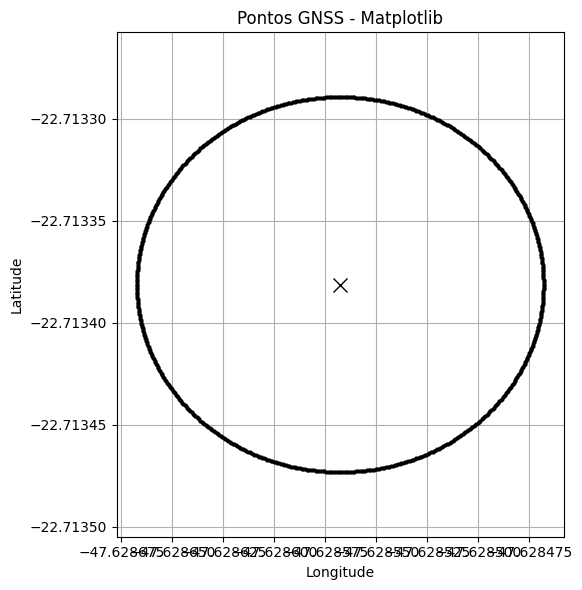

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black')
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=10, label='Ponto de Pivô')
ax.set_title("Pontos GNSS - Matplotlib")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()


In [6]:
# Adiciona os pontos como marcadores circulares
# Criar o mapa centralizado na sua coordenada
map_reference = folium.Map(location=[pivot_lat, pivot_long], zoom_start=14)

for _, row in df_pivot.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="black",
        fill=True,
        fill_opacity=0.7,
        popup=f'Ângulo: {row["angle_deg"]}°'
    ).add_to(map_reference)

folium.CircleMarker(
    location=[pivot_lat, pivot_long],
    radius=2,
    color="black",
    fill=True,
    fill_opacity=0.7,
    popup=f'Ângulo: {row["angle_deg"]}°'
).add_to(map_reference)

# Salva o mapa em HTML
map_reference.save("mapa_pivo_referencia.html")

# Ensaios Realizados

Os ensaios estão organizados da seguinte forma:

- ❌ Volta 1: 12,5 Hz (o esp32 não coletou por conta de problemas na rede de energia, nos proximos foi usado um powerbank)   --> 23/04/25 11:28 até 12:38
- ✅ Volta 2: 12,5 Hz (todos os equipamentos coletaram)   --> 23/04/25 15:51 até 17:01
- ❌ Volta 3: 12,5 Hz (o app SW Maps não coletou)         --> 24/04/25 14:55 até 16:05
- ✅ Volta 4: 25 Hz (todos os equipamentos coletaram)     --> 25/04/25 9:20 até 10:30
- ✅ Volta 5: 25 Hz (todos os equipamentos coletaram)     --> 25/04/25 10:50 até 12:00


- ✅ Volta 6: 25 Hz (todos os equipamentos coletaram)     --> 25/04/25 12:25 até 13:35
- ✅ Volta 7: 12,5 Hz (todos os equipamentos coletaram)   --> 25/04/25 13:58 até 15:08
- ✅ Volta 8: 12,5 Hz (todos os equipamentos coletaram)   --> 25/04/25 15:50 até 17:00

12,5 Hz no inversor corresponde a 2,5 m/s
25 Hz no inversor corresponde a 5 m/s

Foram feitas coletas pontuais antes da volta 4, contudo o método utilizado para coleta foi de 1:10h de coleta e 20m de pausa para dar tempo de mudar a constelação dos satélites. A volta 2 irá compor a volta faltante para a situação de 12,5 HZ.

Os dados foram coletados a cada 5 segundos (0,2Hz).

In [7]:
'''
Como houveram ensaios que nem todos os dispositivos conseguiram coletar, vou organizar da seguinte forma:

 - lap_1 = Volta 4 (25Hz - 5m/s)
 - lap_2 = Volta 5 (25Hz - 5m/s)
 - lap_3 = Volta 6 (25Hz - 5m/s)
 - lap_4 = Volta 7 (12,5Hz - 2,5m/s)
 - lap_5 = Volta 8 (12,5Hz - 2,5m/s)
 - lap_6 = Volta 2 (12,5Hz - 2,5m/s)

'''

laps = {
    "lap_1": {
        "lap_start": "2025-04-25 09:20",
        "lap_end": "2025-04-25 10:30",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
    "lap_2": {
        "lap_start": "2025-04-25 10:50",
        "lap_end": "2025-04-25 12:00",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
    "lap_3": {
        "lap_start": "2025-04-25 12:25",
        "lap_end": "2025-04-25 13:35",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
    "lap_4": {
        "lap_start": "2025-04-25 13:58",
        "lap_end": "2025-04-25 15:08",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
    "lap_5": {
        "lap_start": "2025-04-25 15:50",
        "lap_end": "2025-04-25 17:00",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
    "lap_6": {
        "lap_start": "2025-04-23 15:51",
        "lap_end": "2025-04-23 17:01",
        "esp32": {},
        "celular": {},
        "garmin": {}
    },
}

In [8]:
'''
A estrtura que se busca montar é conforme o exemplo abaixo:


laps = {
    "volta_1": {
        "lap_start": "2025-04-25 09:20",
        "lap_end": "2025-04-25 10:30",
        "esp32": {
            "dataframe": df_esp32_volta_1,  # DataFrame com dados tratados do ESP32
            "erro_analysis": {
                "media_erro_m": 1.23,
                "desvio_erro_m": 0.45,
                "2sigma_m": 0.90,
                "max_erro_m": 2.56,
                "min_erro_m": 0.11,
                "qtd_pontos": 85,
                "erros_metros": [1.1, 1.3, 1.0, ...]
            }
        },
        "celular": {
            "dataframe": df_celular_volta_1,
            "erro_analysis": {
                "media_erro_m": 2.34,
                "desvio_erro_m": 0.78,
                "2sigma_m": 1.56,
                "max_erro_m": 3.45,
                "min_erro_m": 0.89,
                "qtd_pontos": 90,
                "erros_metros": [2.0, 2.5, 2.1, ...]
            }
        },
        "garmin": {
            "dataframe": df_garmin_volta_1,
            "erro_analysis": {
                "media_erro_m": 0.97,
                "desvio_erro_m": 0.32,
                "2sigma_m": 0.64,
                "max_erro_m": 1.50,
                "min_erro_m": 0.50,
                "qtd_pontos": 92,
                "erros_metros": [0.8, 1.1, 1.0, ...]
            }
        }
    },
    "volta_2": {
        "lap_start": "2025-04-25 10:50",
        "lap_end": "2025-04-25 12:00",
        "esp32": {
            "dataframe": ...,
            "erro_analysis": {...}
        },
        "celular": {
            "dataframe": ...,
            "erro_analysis": {...}
        },
        "garmin": {
            "dataframe": ...,
            "erro_analysis": {...}
        }
    },
    ...
}
'''

'\nA estrtura que se busca montar é conforme o exemplo abaixo:\n\n\nlaps = {\n    "volta_1": {\n        "lap_start": "2025-04-25 09:20",\n        "lap_end": "2025-04-25 10:30",\n        "esp32": {\n            "dataframe": df_esp32_volta_1,  # DataFrame com dados tratados do ESP32\n            "erro_analysis": {\n                "media_erro_m": 1.23,\n                "desvio_erro_m": 0.45,\n                "2sigma_m": 0.90,\n                "max_erro_m": 2.56,\n                "min_erro_m": 0.11,\n                "qtd_pontos": 85,\n                "erros_metros": [1.1, 1.3, 1.0, ...]\n            }\n        },\n        "celular": {\n            "dataframe": df_celular_volta_1,\n            "erro_analysis": {\n                "media_erro_m": 2.34,\n                "desvio_erro_m": 0.78,\n                "2sigma_m": 1.56,\n                "max_erro_m": 3.45,\n                "min_erro_m": 0.89,\n                "qtd_pontos": 90,\n                "erros_metros": [2.0, 2.5, 2.1, ...]\n    

## ESP32

In [9]:

df_esp_250_1 = pd.read_csv('Dados/esp32_volta_4.csv') # 25Hz inversor = 2,5ms - lap_1
df_esp_250_2 = pd.read_csv('Dados/esp32_volta_5.csv') # 25Hz inversor = 2,5ms - lap_2
df_esp_250_3 = pd.read_csv('Dados/esp32_volta_6.csv') # 25Hz inversor = 2,5ms - lap_3

df_esp_125_1 = pd.read_csv('Dados/esp32_volta_7.csv') # 12,5Hz inversor = 2,5ms - lap_4
df_esp_125_2 = pd.read_csv('Dados/esp32_volta_8.csv') # 12,5Hz inversor = 2,5ms - lap_5
df_esp_125_3 = pd.read_csv('Dados/esp32_volta_2.csv') # 12,5Hz inversor = 2,5ms - lap_6


laps["lap_1"]["esp32"]["dataframe"] = df_esp_250_1
laps["lap_2"]["esp32"]["dataframe"] = df_esp_250_2
laps["lap_3"]["esp32"]["dataframe"] = df_esp_250_3
laps["lap_4"]["esp32"]["dataframe"] = df_esp_125_1
laps["lap_5"]["esp32"]["dataframe"] = df_esp_125_2
laps["lap_6"]["esp32"]["dataframe"] = df_esp_125_3

laps["lap_6"]["esp32"]["dataframe"]


,2025-04-23 15:54:15,2025-4-23 18:54:15,-22.713407,-47.628441,543.300000,0.87,10
0,2025-04-23 15:54:17,2025-4-23 18:54:16,-22.713423,-47.628442,543.2,0.87,10
1,2025-04-23 15:54:18,2025-4-23 18:54:17,-22.713440,-47.628447,543.1,0.87,10
2,2025-04-23 15:54:19,2025-4-23 18:54:19,-22.713468,-47.628464,543.1,0.87,10
3,2025-04-23 15:54:20,2025-4-23 18:54:20,-22.713479,-47.628477,543.4,0.87,10
4,2025-04-23 15:54:21,2025-4-23 18:54:21,-22.713489,-47.628491,543.4,0.87,10
...,...,...,...,...,...,...,...
3292,2025-04-23 16:54:10,2025-4-23 19:54:10,-22.713385,-47.628626,546.8,1.18,9
3293,2025-04-23 16:54:11,2025-4-23 19:54:11,-22.713372,-47.628616,546.9,0.93,10
3294,2025-04-23 16:54:12,2025-4-23 19:54:12,-22.713360,-47.628603,547.0,0.93,10
3295,2025-04-23 16:54:13,2025-4-23 19:54:13,-22.713351,-47.628588,546.9,0.93,10


In [10]:
# Percorrendo as chaves do dicionário, estou renomeando as colunas, cortando os dados capturados fora do range de lap_start e lap_end e
# diminuindo a frequência de coleta, pois o esp32 eu configurei para coletar a cada 1 seg e selecionei dados a cada 5 seg

for lap_name, lap_data in laps.items():
    # Verifica se há dados em esp32 e se "dataframe" está presente
    if "dataframe" in lap_data.get("esp32", {}):
        dataframe = lap_data["esp32"]["dataframe"]

        # Renomeia as colunas
        dataframe.columns = ['timestamp_net', 'timestamp_gps', 'latitude', 'longitude', 'altitude', 'hdop', 'satélites']
        
        # Converte a coluna 'timestamp_net' para datetime
        dataframe['timestamp_net'] = pd.to_datetime(dataframe['timestamp_net'])
        
        # Usa o lap_start e lap_end da volta como timestamps e tirando os 5 primeiros e os 5 últimos minutos
        start_time = pd.Timestamp(lap_data["lap_start"]) + pd.Timedelta(minutes=5)
        end_time = pd.Timestamp(lap_data["lap_end"]) - pd.Timedelta(minutes=5)
        
        # Filtra os dados dentro do intervalo de tempo da volta
        dataframe = dataframe[
            (dataframe['timestamp_net'] >= start_time) &
            (dataframe['timestamp_net'] <= end_time)
        ]
        
        # Ordena por timestamp e reseta o índice
        dataframe = dataframe.sort_values('timestamp_net').reset_index(drop=True)
        
        # Seleciona linhas com múltiplos de 5 segundos exatos a partir do start_time
        dataframe = dataframe[((dataframe['timestamp_net'] - start_time).dt.total_seconds() % 5 == 0)]
        
        # Atualiza o dataframe tratado no dicionário
        laps[lap_name]["esp32"]["dataframe"] = dataframe



In [11]:
laps["lap_1"]["esp32"]["dataframe"]

,timestamp_net,timestamp_gps,latitude,longitude,altitude,hdop,satélites
0,2025-04-25 09:25:00,2025-4-25 12:25:0,-22.713293,-47.628612,547.5,1.13,10
5,2025-04-25 09:25:05,2025-4-25 12:25:5,-22.713366,-47.628478,547.6,0.91,10
9,2025-04-25 09:25:10,2025-4-25 12:25:10,-22.713470,-47.628592,547.1,0.91,10
14,2025-04-25 09:25:15,2025-4-25 12:25:15,-22.713342,-47.628664,547.8,0.82,11
19,2025-04-25 09:25:20,2025-4-25 12:25:20,-22.713310,-47.628510,547.7,0.91,10
...,...,...,...,...,...,...,...
3288,2025-04-25 10:24:35,2025-4-25 13:24:35,-22.713426,-47.628667,549.6,0.85,10
3293,2025-04-25 10:24:40,2025-4-25 13:24:40,-22.713290,-47.628611,549.1,0.85,10
3302,2025-04-25 10:24:50,2025-4-25 13:24:50,-22.713464,-47.628607,549.7,0.95,9
3307,2025-04-25 10:24:55,2025-4-25 13:24:55,-22.713330,-47.628670,549.8,0.85,10


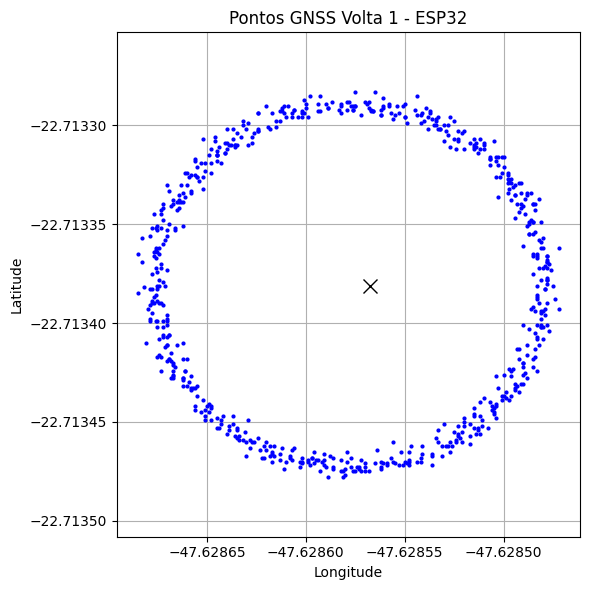

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot( laps['lap_1']["esp32"]["dataframe"]["longitude"], laps['lap_1']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue')
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=10, label='Ponto de Pivô')
ax.set_title("Pontos GNSS Volta 1 - ESP32")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()


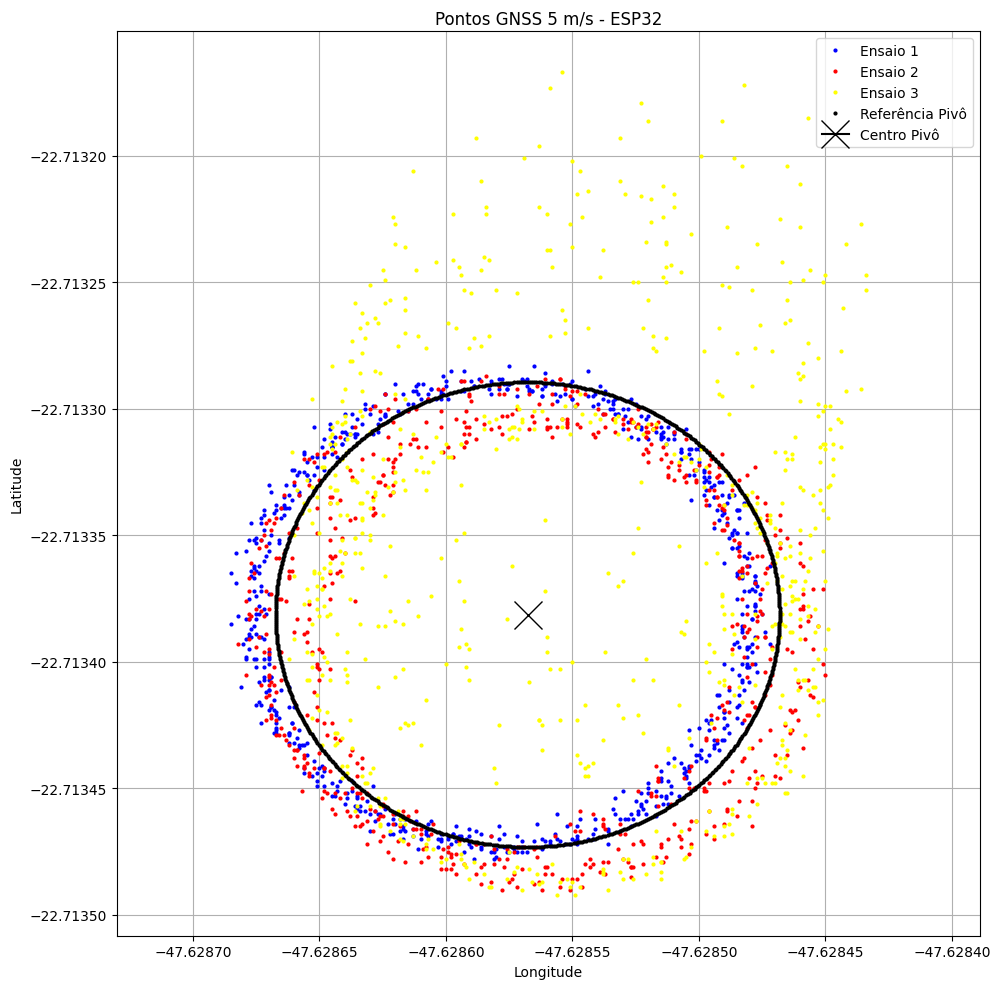

In [112]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_1']["esp32"]["dataframe"]["longitude"], laps['lap_1']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue', label="Ensaio 1")
ax.plot( laps['lap_2']["esp32"]["dataframe"]["longitude"], laps['lap_2']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='red', label="Ensaio 2")
ax.plot( laps['lap_3']["esp32"]["dataframe"]["longitude"], laps['lap_3']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='yellow', label="Ensaio 3")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 5 m/s - ESP32")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

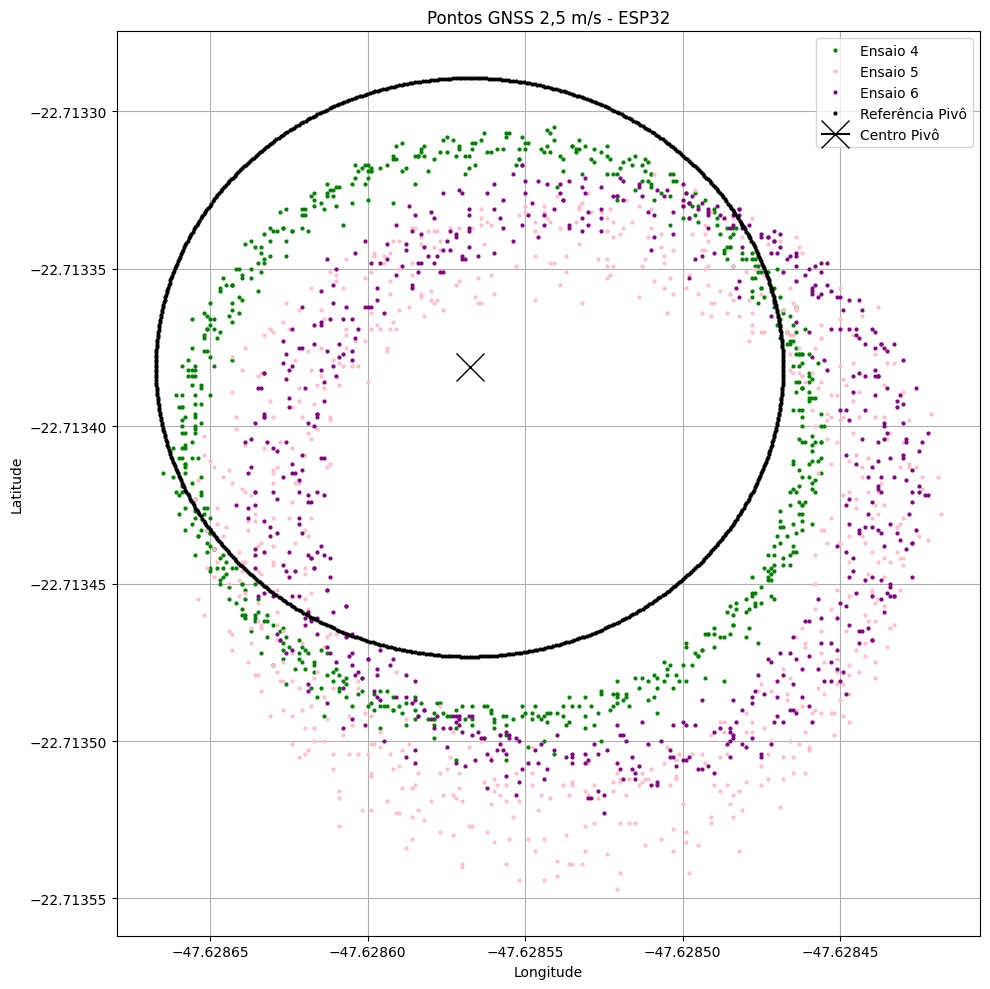

In [143]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_4']["esp32"]["dataframe"]["longitude"], laps['lap_4']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='green', label="Ensaio 4")
ax.plot( laps['lap_5']["esp32"]["dataframe"]["longitude"], laps['lap_5']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='pink', label="Ensaio 5")
ax.plot( laps['lap_6']["esp32"]["dataframe"]["longitude"], laps['lap_6']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='purple', label="Ensaio 6")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 2,5 m/s - ESP32")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

In [15]:
# Primeiro, criar o mapa centralizado no seu pivô
map_esp32 = folium.Map(location=[pivot_lat, pivot_long], zoom_start=17, tiles="OpenStreetMap")

# Definindo as voltas, cores e nomes
laps_to_plot = ['lap_1', 'lap_2', 'lap_3', 'lap_4', 'lap_5', 'lap_6']
colors = ['blue', 'red', 'yellow', 'green', 'purple', 'orange']
labels = ['Ensaio 1', 'Ensaio 2', 'Ensaio 3', 'Ensaio 4', 'Ensaio 5', 'Ensaio 6']

# Adiciona os pontos de cada volta
for lap_name, color, label in zip(laps_to_plot, colors, labels):
    df_esp = laps[lap_name]["esp32"].get("dataframe")
    if df_esp is not None:
        for _, row in df_esp.iterrows():
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=2,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                popup=f"{label}"
            ).add_to(map_esp32)

# Adiciona os pontos de referência do pivô
for _, row in df_pivot.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        popup="Referência Pivô"
    ).add_to(map_esp32)

# Adiciona o centro do pivô
folium.Marker(
    location=[pivot_lat, pivot_long],
    icon=folium.Icon(color='black', icon='star'),
    popup="Centro Pivô"
).add_to(map_esp32)

# Salva o mapa
map_esp32.save("mapa_esp32.html")

## Celular

In [21]:
df_celular_250_1 = pd.read_excel('Dados/celular_volta_4.xlsx') # 25Hz inversor = 2,5ms - lap_1
df_celular_250_2 = pd.read_excel('Dados/celular_volta_5.xlsx') # 25Hz inversor = 2,5ms - lap_2
df_celular_250_3 = pd.read_excel('Dados/celular_volta_6.xlsx') # 25Hz inversor = 2,5ms - lap_3

df_celular_125_1 = pd.read_excel('Dados/celular_volta_7.xlsx') # 12,5Hz inversor = 2,5ms - lap_4
df_celular_125_2 = pd.read_excel('Dados/celular_volta_8.xlsx') # 12,5Hz inversor = 2,5ms - lap_5
df_celular_125_3 = pd.read_excel('Dados/celular_volta_2.xlsx') # 12,5Hz inversor = 2,5ms - lap_6


laps["lap_1"]["celular"]["dataframe"] = df_celular_250_1
laps["lap_2"]["celular"]["dataframe"] = df_celular_250_2
laps["lap_3"]["celular"]["dataframe"] = df_celular_250_3
laps["lap_4"]["celular"]["dataframe"] = df_celular_125_1
laps["lap_5"]["celular"]["dataframe"] = df_celular_125_2
laps["lap_6"]["celular"]["dataframe"] = df_celular_125_3

laps["lap_6"]["celular"]["dataframe"]

,Track Name,Time,Geometry,Lat,Lon,X,Y,Elevation,Ortho Height,Instrument Ht,Fix ID,Speed,Bearing,Horizontal Accuracy,Vertical Accuracy,PDOP,HDOP,VDOP,Satellites in View,Satellites in Use
0,volta 4,04/23/2025 15:49:15.000 GMT-03:00,"POINT Z (-47,628639033 -22,713400617 542,300)",-22713400617,-47628639033,229980751.0,7.485813e+09,542.3,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,26,21
1,volta 4,04/23/2025 15:49:20.000 GMT-03:00,"POINT Z (-47,628639333 -22,713399817 543,100)",-22713399817,-47628639333,229980719.0,7.485813e+09,543.1,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,29,23
2,volta 4,04/23/2025 15:49:25.000 GMT-03:00,"POINT Z (-47,628639050 -22,713400100 543,400)",-227134001,-4762863905,229980748.0,7.485813e+09,543.4,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,30,24
3,volta 4,04/23/2025 15:49:30.000 GMT-03:00,"POINT Z (-47,628639250 -22,713399983 543,500)",-22713399983,-4762863925,229980727.0,7.485813e+09,543.5,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,31,24
4,volta 4,04/23/2025 15:49:35.000 GMT-03:00,"POINT Z (-47,628638933 -22,713400583 543,400)",-22713400583,-47628638933,229980761.0,7.485813e+06,543.4,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,30,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,volta 4,04/23/2025 17:01:55.000 GMT-03:00,"POINT Z (-47,628634133 -22,713472800 545,000)",-227134728,-47628634133,229981396.0,7.485805e+09,545.0,0,0,1,0.772,328.4,3.79,2.5,0,0,0,30,25
873,volta 4,04/23/2025 17:02:00.000 GMT-03:00,"POINT Z (-47,628645533 -22,713441117 545,600)",-22713441117,-47628645533,229980162.0,7.485809e+09,545.6,0,0,1,0.720,329.2,3.79,2.5,0,0,0,29,25
874,volta 4,04/23/2025 17:02:05.000 GMT-03:00,"POINT Z (-47,628642033 -22,713404833 546,100)",-22713404833,-47628642033,229980451.0,7.485813e+09,546.1,0,0,1,0.772,358.6,3.79,2.5,0,0,0,30,24
875,volta 4,04/23/2025 17:02:10.000 GMT-03:00,"POINT Z (-47,628633383 -22,713388983 546,100)",-22713388983,-47628633383,229981309.0,7.485815e+09,546.1,0,0,1,0.000,-1.0,3.79,2.5,0,0,0,29,25


In [22]:
# Função para limpar e formatar as coordenadas, pois o celular fornece a string meio estranha, como: -22485693359 ao invés de -22.485693359
def clean_coord(val):
    try:
        if pd.isna(val):
            return None
        val = str(val).replace('.', '')  # Remove todos os pontos
        if len(val) < 3:
            return None  # Muito curto pra ser coordenada válida
        return float(val[:3] + '.' + val[3:])  # Ex: "22713333" → 22.713333
    except Exception:
        return None

# Percorrendo as chaves do dicionário, cortando os dados capturados fora do range de lap_start e lap_end e manipulando a string para
# ela fica no padrão de -22.12412 pois atualmente não tem um ponto dividindo
for lap_name, lap_data in laps.items():
    
    df_cel = lap_data.get("celular", {}).get("dataframe")
    if df_cel is None or df_cel.empty:
        continue

    # Converte a coluna 'Time' para datetime e localiza no fuso de SP
    df_cel['Time'] = pd.to_datetime(df_cel['Time'])

    # Cria timestamps de início e fim já com fuso e tirando os 5 primeiros e os 5 últimos minutos
    start_time = pd.Timestamp(lap_data["lap_start"]).tz_localize("America/Sao_Paulo") + pd.Timedelta(minutes=5)
    end_time   = pd.Timestamp(lap_data["lap_end"]).tz_localize("America/Sao_Paulo") - pd.Timedelta(minutes=5)


    # Filtra pelo intervalo da volta
    df_cel = df_cel[(df_cel['Time'] >= start_time) & (df_cel['Time'] <= end_time)]

    # Ordena e reseta índice
    df_cel = df_cel.sort_values('Time').reset_index(drop=True)

    # Limpa as coordenadas brutas
    df_cel['Lat'] = df_cel['Lat'].apply(clean_coord)
    df_cel['Lon'] = df_cel['Lon'].apply(clean_coord)

    df_cel.rename(columns={'Lat': 'latitude', 'Lon': 'longitude'}, inplace=True)

    # Reatribui o DataFrame tratado ao dicionário
    laps[lap_name]["celular"]["dataframe"] = df_cel

In [23]:
laps["lap_6"]["celular"]["dataframe"]

,Track Name,Time,Geometry,latitude,longitude,X,Y,Elevation,Ortho Height,Instrument Ht,Fix ID,Speed,Bearing,Horizontal Accuracy,Vertical Accuracy,PDOP,HDOP,VDOP,Satellites in View,Satellites in Use
0,volta 4,2025-04-23 15:56:00-03:00,"POINT Z (-47,628444167 -22,713450733 542,500)",-22.713451,-47.628444,230000876.0,7.485808e+06,542.5,0,0,1,1903.0,197.8,3.79,2.5,0,0,0,31,25
1,volta 4,2025-04-23 15:56:05-03:00,"POINT Z (-47,628518667 -22,713506317 542,700)",-22.713506,-47.628519,229993329.0,7.485802e+09,542.7,0,0,1,1903.0,250.4,3.79,2.5,0,0,0,31,26
2,volta 4,2025-04-23 15:56:10-03:00,"POINT Z (-47,628611833 -22,713485017 542,900)",-22.713485,-47.628612,229983712.0,7.485804e+09,542.9,0,0,1,1955.0,303.6,3.79,2.5,0,0,0,31,26
3,volta 4,2025-04-23 15:56:15-03:00,"POINT Z (-47,628649450 -22,713402950 543,400)",-22.713403,-47.628649,229979685.0,7.485813e+09,543.4,0,0,1,1903.0,356.7,3.79,2.5,0,0,0,31,27
4,volta 4,2025-04-23 15:56:20-03:00,"POINT Z (-47,628600567 -22,713325867 543,900)",-22.713326,-47.628601,229984557.0,7.485822e+09,543.9,0,0,1,1903.0,49.4,3.79,2.5,0,0,0,31,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,volta 4,2025-04-23 16:55:40-03:00,"POINT Z (-47,628526183 -22,713518667 543,300)",-22.713519,-47.628526,229992581.0,7.485800e+09,543.3,0,0,1,1955.0,251.0,3.79,2.5,0,0,0,29,23
717,volta 4,2025-04-23 16:55:45-03:00,"POINT Z (-47,628617517 -22,713495867 543,200)",-22.713496,-47.628618,229983149.0,7.485803e+09,543.2,0,0,1,1903.0,303.8,3.79,2.5,0,0,0,28,22
718,volta 4,2025-04-23 16:55:50-03:00,"POINT Z (-47,628655833 -22,713415917 543,700)",-22.713416,-47.628656,229979054.0,7.485812e+09,543.7,0,0,1,1903.0,356.7,3.79,2.5,0,0,0,29,24
719,volta 4,2025-04-23 16:55:55-03:00,"POINT Z (-47,628606050 -22,713338617 543,900)",-22.713339,-47.628606,229984019.0,7.485820e+09,543.9,0,0,1,1903.0,49.6,3.79,2.5,0,0,0,30,23


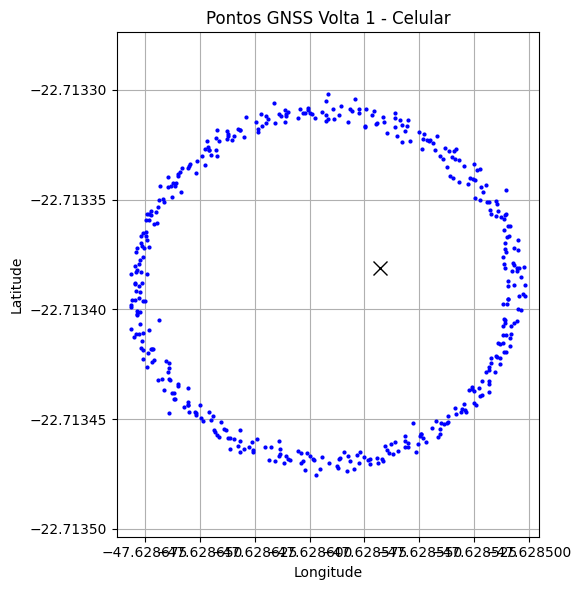

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(laps['lap_1']["celular"]["dataframe"]["longitude"], laps['lap_1']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue')
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=10, label='Ponto de Pivô')
ax.set_title("Pontos GNSS Volta 1 - Celular")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

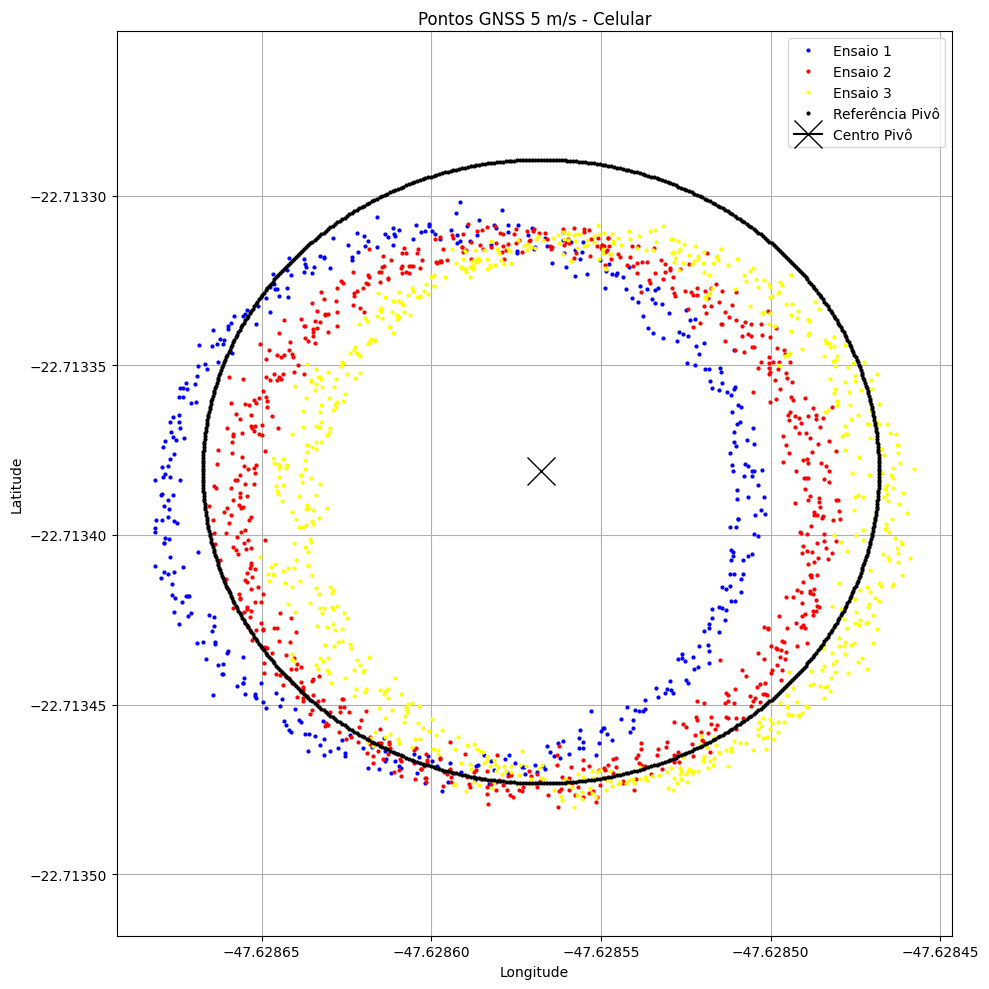

In [115]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_1']["celular"]["dataframe"]["longitude"], laps['lap_1']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue', label="Ensaio 1")
ax.plot( laps['lap_2']["celular"]["dataframe"]["longitude"], laps['lap_2']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='red', label="Ensaio 2")
ax.plot( laps['lap_3']["celular"]["dataframe"]["longitude"], laps['lap_3']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='yellow', label="Ensaio 3")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 5 m/s - Celular")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

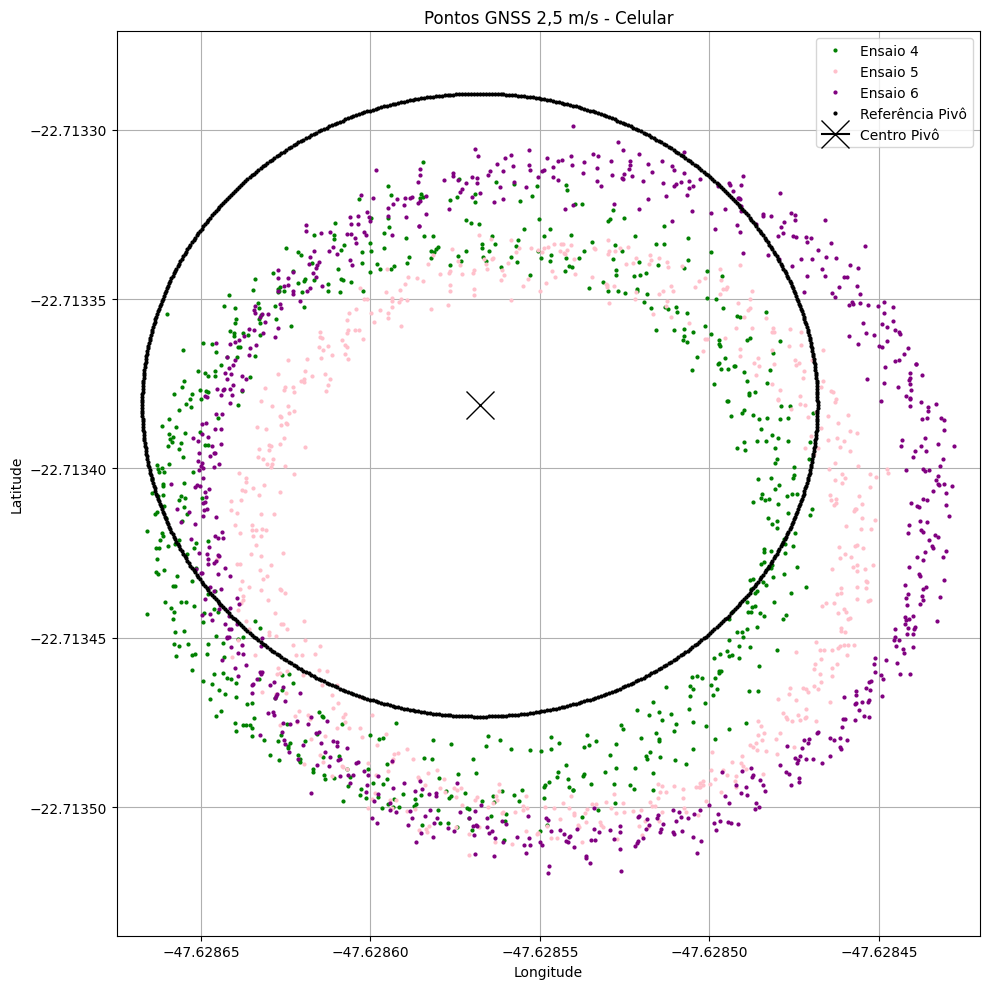

In [144]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_4']["celular"]["dataframe"]["longitude"], laps['lap_4']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='green', label="Ensaio 4")
ax.plot( laps['lap_5']["celular"]["dataframe"]["longitude"], laps['lap_5']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='pink', label="Ensaio 5")
ax.plot( laps['lap_6']["celular"]["dataframe"]["longitude"], laps['lap_6']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='purple', label="Ensaio 6")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 2,5 m/s - Celular")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

In [27]:
# Primeiro, criar o mapa centralizado no seu pivô
map_celular = folium.Map(location=[pivot_lat, pivot_long], zoom_start=17, tiles="OpenStreetMap")

# Definindo as voltas, cores e nomes
laps_to_plot = ['lap_1', 'lap_2', 'lap_3', 'lap_4', 'lap_5', 'lap_6']
colors = ['blue', 'red', 'yellow', 'green', 'purple', 'orange']
labels = ['Ensaio 1', 'Ensaio 2', 'Ensaio 3', 'Ensaio 4', 'Ensaio 5', 'Ensaio 6']

# Adiciona os pontos de cada volta
for lap_name, color, label in zip(laps_to_plot, colors, labels):
    if "celular" in laps[lap_name] and "dataframe" in laps[lap_name]["celular"]:
        df = laps[lap_name]["celular"]["dataframe"]
        for _, row in df.iterrows():
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=2,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                popup=f"{label}"
            ).add_to(map_celular)

# Adiciona os pontos de referência do pivô
for _, row in df_pivot.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        popup="Referência Pivô"
    ).add_to(map_celular)

# Adiciona o centro do pivô
folium.Marker(
    location=[pivot_lat, pivot_long],
    icon=folium.Icon(color='black', icon='star'),
    popup="Centro Pivô"
).add_to(map_celular)

# Salva o mapa
map_celular.save("mapa_celular.html")


## Garmin

In [28]:
'''
    Para carregar os dados do garmin, foi necessário utilizar uma outra abordagem, tendo em vista que sua saída é em csv, mas a estrutura
    do arquivo está toda bagunçada, sendo necessário remover alguns conteúdos na mão e posteriormente carregar o arquivo pensando em uma divisão
    por tabulação.

    CORREÇÂO: alguns arquivos estavam separados por vírgula, não sei o que aconteceu na hora da exportação dos dados
'''

with open("Dados/garmin_volta_4.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_250_1 = pd.read_csv(io.StringIO(texto), sep="\t", engine="python")

with open("Dados/garmin_volta_5.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_250_2 = pd.read_csv(io.StringIO(texto), sep="\t", engine="python")

with open("Dados/garmin_volta_6.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_250_3 = pd.read_csv(io.StringIO(texto), sep=",", engine="python")

with open("Dados/garmin_volta_7.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_125_1 = pd.read_csv(io.StringIO(texto), sep=",", engine="python")

with open("Dados/garmin_volta_8.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_125_2 = pd.read_csv(io.StringIO(texto), sep="\t", engine="python")


with open("Dados/garmin_volta_2.csv", "r", encoding="utf-8") as f:
    texto = f.read().replace('"', '')
df_garmin_125_3 = pd.read_csv(io.StringIO(texto), sep="\t", engine="python")



laps["lap_1"]["garmin"]["dataframe"] = df_garmin_250_1
laps["lap_2"]["garmin"]["dataframe"] = df_garmin_250_2
laps["lap_3"]["garmin"]["dataframe"] = df_garmin_250_3
laps["lap_4"]["garmin"]["dataframe"] = df_garmin_125_1
laps["lap_5"]["garmin"]["dataframe"] = df_garmin_125_2
laps["lap_6"]["garmin"]["dataframe"] = df_garmin_125_3

print(laps["lap_1"]["garmin"]["dataframe"].shape)
print(laps["lap_2"]["garmin"]["dataframe"].shape)
print(laps["lap_3"]["garmin"]["dataframe"].shape)
print(laps["lap_4"]["garmin"]["dataframe"].shape)
print(laps["lap_5"]["garmin"]["dataframe"].shape)
print(laps["lap_6"]["garmin"]["dataframe"].shape)


(1094, 30)
(1007, 30)
(1083, 27)
(1126, 27)
(860, 26)
(1396, 30)


In [29]:
laps["lap_6"]["garmin"]["dataframe"]

,ID,trksegID,lat,lon,ele,time,magvar,geoidheight,name,cmt,...,dgpsid,Temperature,Depth,wtemp,hr,cad,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,1,1.0,-22.713.475.339.114.600,-47.628.267.528.489.200,627.397.705.078.125,2025-04-23T18:09:54Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.0,-22.713.442.984.968.400,-47.628.420.330.584.000,58.702.197.265.625,2025-04-23T18:09:59Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1.0,-22.713.390.681.892.600,-47.628.602.385.520.900,555.779.296.875,2025-04-23T18:10:04Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1.0,-22.713.394.621.387.100,-47.628.595.931.455.400,55.481.787.109.375,2025-04-23T18:10:09Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1.0,-22.713.398.141.786.400,-47.628.578.580.915.900,556.260.009.765.625,2025-04-23T18:10:14Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1391,1392,1.0,-227.133.958.786.726,-47.628.631.554.543.900,54.424.365.234.375,2025-04-23T20:05:50Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1392,1393,1.0,-22.713.396.046.310.600,-47.628.631.722.182.000,54.424.365.234.375,2025-04-23T20:05:55Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1393,1394,1.0,-22.713.396.046.310.600,-47.628.631.973.639.100,54.424.365.234.375,2025-04-23T20:06:00Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1394,1395,1.0,-22.713.396.046.310.600,-47.628.632.057.458.100,54.424.365.234.375,2025-04-23T20:06:03Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Função para limpar e formatar as coordenadas, pois o garmin fornece a string meio estranha, como: -22485693359 ao invés de -22.485693359
# também vou ajustar a hora da minha coluna, pois está 3 horas adiantada
def clean_coord(val):
    try:
        if pd.isna(val):
            return None
        s = str(val).replace('.', '')
        if len(s) < 3:
            return None
        # Ajusta para ter 2 dígitos antes do ponto
        return float(s[:3] + '.' + s[3:])
    except Exception:
        return None

for lap_name, lap_data in laps.items():
    df_gar = lap_data.get("garmin", {}).get("dataframe")
    if df_gar is None or df_gar.empty:
        continue

    # print(df_gar["time"])

    df_gar['time'] = (
        pd.to_datetime(df_gar['time'])
          .dt.tz_convert(None)            # remove timezone se já tiver
          - pd.Timedelta(hours=3)         # Garmin grava +3h
    ).dt.tz_localize("America/Sao_Paulo")  # aplica fuso SP


    start = pd.Timestamp(lap_data['lap_start']).tz_localize("America/Sao_Paulo") + pd.Timedelta(minutes=5)
    end   = pd.Timestamp(lap_data['lap_end'  ]).tz_localize("America/Sao_Paulo") - pd.Timedelta(minutes=5)
    df_gar = df_gar[(df_gar['time'] >= start) & (df_gar['time'] <= end)]

    df_gar = df_gar.sort_values('time').reset_index(drop=True)


    df_gar['lat'] = df_gar['lat'].apply(clean_coord)
    df_gar['lon'] = df_gar['lon'].apply(clean_coord)

    drop_cols = [c for c in df_gar.columns if c.startswith("Unnamed:")]
    df_gar = df_gar.drop(columns=drop_cols)

    df_gar.rename(columns={'lat': 'latitude', 'lon': 'longitude'}, inplace=True)


    laps[lap_name]["garmin"]["dataframe"] = df_gar

In [31]:
laps["lap_6"]["garmin"]["dataframe"]

,ID,trksegID,latitude,longitude,ele,time,magvar,geoidheight,name,cmt,...,hdop,vdop,pdop,ageofdgpsdata,dgpsid,Temperature,Depth,wtemp,hr,cad
0,554,1.0,-22.713454,-47.628448,5.384.757.080.078.120,2025-04-23 15:56:00-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,555,1.0,-22.713507,-47.628517,5.384.757.080.078.120,2025-04-23 15:56:05-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,556,1.0,-22.713485,-47.628602,538.956.298.828.125,2025-04-23 15:56:10-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,557,1.0,-22.713406,-47.628645,5.384.757.080.078.120,2025-04-23 15:56:15-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,558,1.0,-22.713340,-47.628601,538.956.298.828.125,2025-04-23 15:56:20-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,1270,1.0,-22.713531,-47.628526,5.432.821.044.921.870,2025-04-23 16:55:40-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
717,1271,1.0,-22.713505,-47.628611,5.432.821.044.921.870,2025-04-23 16:55:45-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
718,1272,1.0,-22.713422,-47.628646,5.432.821.044.921.870,2025-04-23 16:55:50-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719,1273,1.0,-22.713347,-47.628605,542.801.513.671.875,2025-04-23 16:55:55-03:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


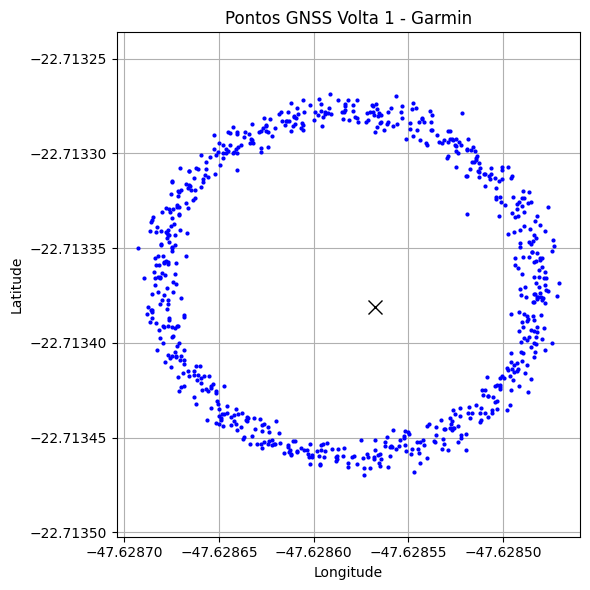

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(laps['lap_1']["garmin"]["dataframe"]["longitude"], laps['lap_1']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue')
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=10, label='Ponto de Pivô')
ax.set_title("Pontos GNSS Volta 1 - Garmin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

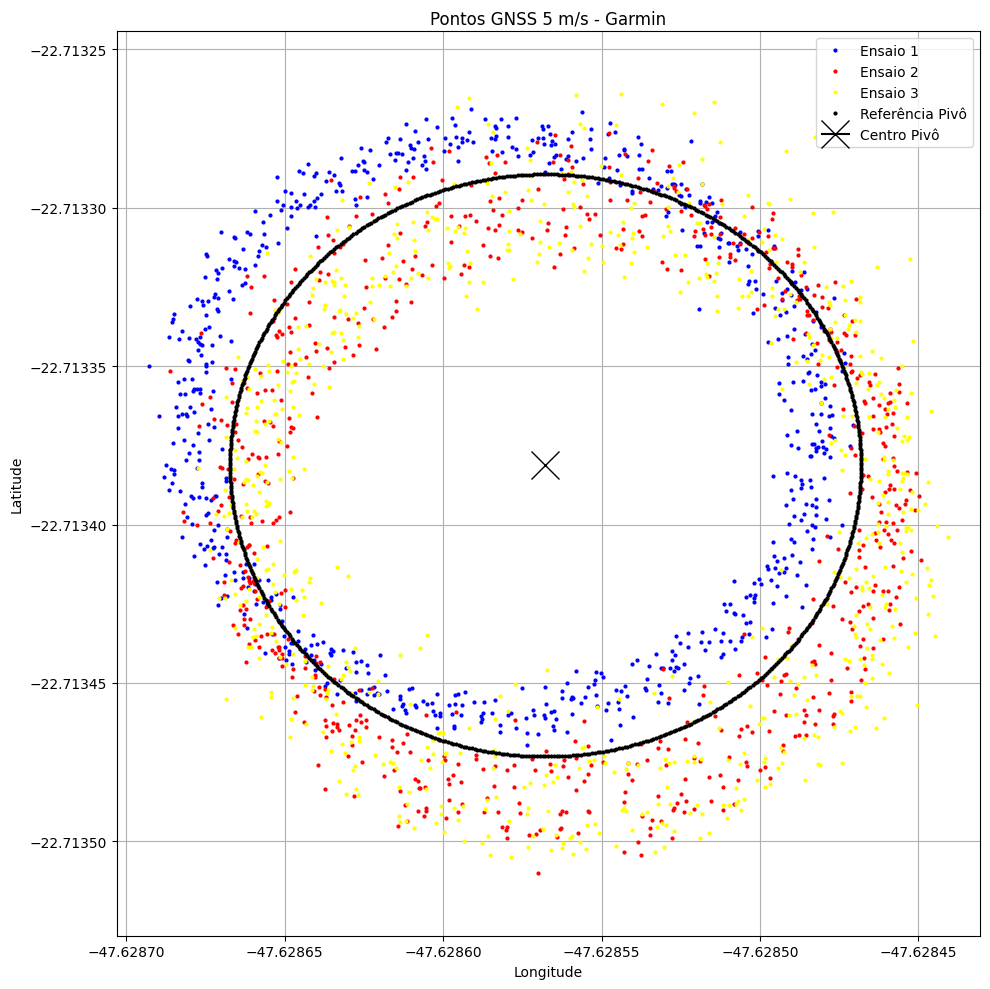

In [118]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_1']["garmin"]["dataframe"]["longitude"], laps['lap_1']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue', label="Ensaio 1")
ax.plot( laps['lap_2']["garmin"]["dataframe"]["longitude"], laps['lap_2']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='red', label="Ensaio 2")
ax.plot( laps['lap_3']["garmin"]["dataframe"]["longitude"], laps['lap_3']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='yellow', label="Ensaio 3")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 5 m/s - Garmin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

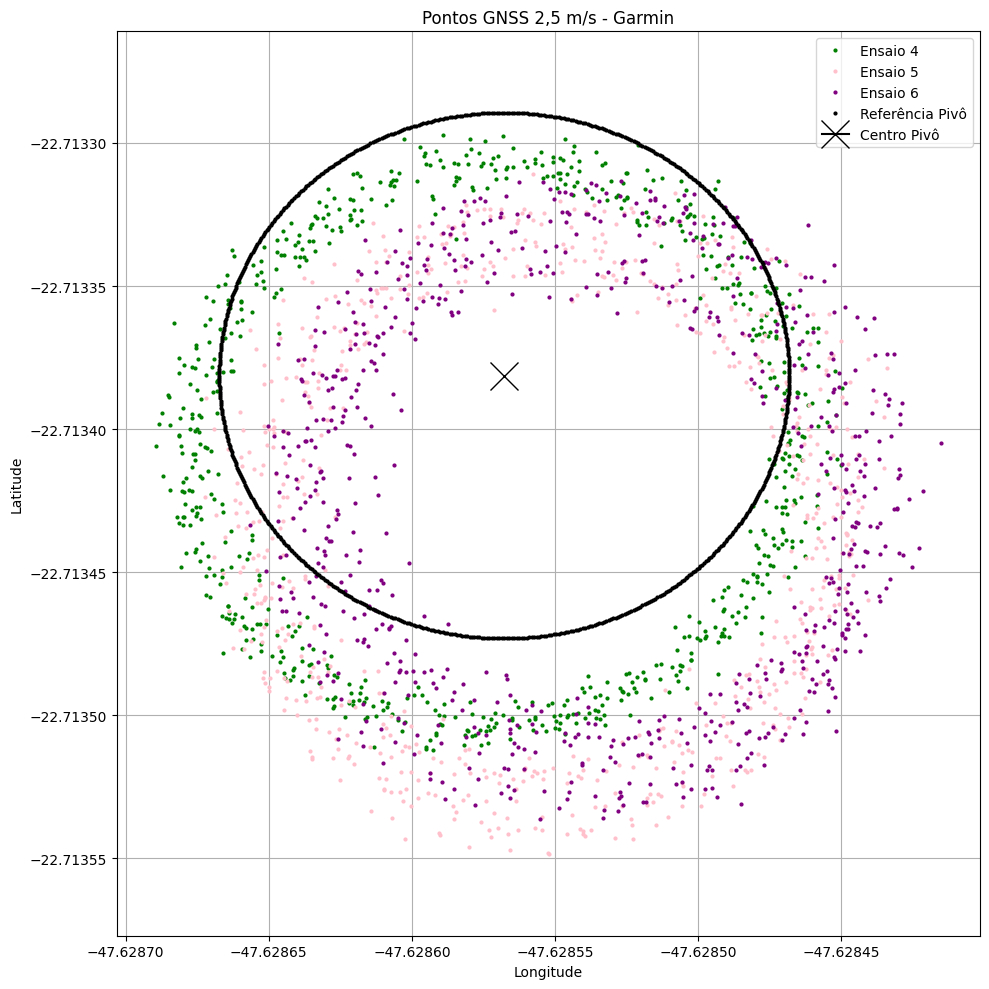

In [145]:
fig, ax = plt.subplots(figsize=(10, 10))


ax.plot( laps['lap_4']["garmin"]["dataframe"]["longitude"], laps['lap_4']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='green', label="Ensaio 4")
ax.plot( laps['lap_5']["garmin"]["dataframe"]["longitude"], laps['lap_5']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='pink', label="Ensaio 5")
ax.plot( laps['lap_6']["garmin"]["dataframe"]["longitude"], laps['lap_6']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='purple', label="Ensaio 6")

ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS 2,5 m/s - Garmin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

## Erro Transversal/Radial
Método pedido pelo professor e somente com EMP, Desvio Padrão e 2sigma


In [ ]:
results = []

for lap_name in laps.keys():
    lap_df = laps[lap_name]["esp32"].get("dataframe")
    
    if lap_df is None or lap_df.empty:
        continue

    transverse_errors = []
    for _, lap_point in lap_df.iterrows():

        # Distância geodésica entre ponto GNSS e centro do pivô
        distance = geodesic((pivot_lat, pivot_long), (lap_point['latitude'], lap_point['longitude'])).meters
        error = abs(radius_m - distance)

        transverse_errors.append(error)

    emp = np.mean(transverse_errors)

    deviations = []
    for transverse_error in transverse_errors:
        deviation = (transverse_error - emp) ** 2
        deviations.append(deviation)

    std_dev = sqrt(np.mean(deviations))
    _2sigma = 2 * std_dev

    # print(lap_name)
    # print("EMP:", emp)
    # print("Desvio Padrão:", std_dev)
    # print("2 Sigma:", _2sigma)
    # print("----------------------")

    # Armazena os resultados em uma lista de dicionários
    results.append({
        'Volta': lap_name,
        'EMP': emp,
        'Desvio Padrão': std_dev,
        '2σ': _2sigma,
        'N Pontos': len(transverse_errors)
    })

# Cria DataFrame com todos os resultados
results_df = pd.DataFrame(results)

    

lap_1
EMP: 0.7059170551136141
Desvio Padrão: 0.4443227113910394
2 Sigma: 0.8886454227820788
----------------------
lap_2
EMP: 1.0135531358867118
Desvio Padrão: 0.609432221638387
2 Sigma: 1.218864443276774
----------------------
lap_3
EMP: 2.9545743233467467
Desvio Padrão: 2.730727116029694
2 Sigma: 5.461454232059388
----------------------
lap_4
EMP: 1.6242756588038787
Desvio Padrão: 0.8518755799805691
2 Sigma: 1.7037511599611381
----------------------
lap_5
EMP: 4.02758501255375
Desvio Padrão: 2.1514491231870534
2 Sigma: 4.302898246374107
----------------------
lap_6
EMP: 3.4413300312693496
Desvio Padrão: 1.7938893929948387
2 Sigma: 3.5877787859896775
----------------------


In [ ]:
results_df

,Volta,EMP,Desvio Padrão,2σ,N Pontos
0,lap_1,0.705917,0.444323,0.888645,670
1,lap_2,1.013553,0.609432,1.218864,661
2,lap_3,2.954574,2.730727,5.461454,702
3,lap_4,1.624276,0.851876,1.703751,702
4,lap_5,4.027585,2.151449,4.302898,707
5,lap_6,3.441330,1.793889,3.587779,632


In [34]:
# Cria o mapa centralizado no pivô
map_garmin = folium.Map(location=[pivot_lat, pivot_long], zoom_start=17, tiles="OpenStreetMap")

# Define as voltas, cores e rótulos
laps_to_plot = ['lap_1', 'lap_2', 'lap_3', 'lap_4', 'lap_5', 'lap_6']
colors = ['blue', 'red', 'yellow', 'green', 'purple', 'orange']
labels = ['Ensaio 1', 'Ensaio 2', 'Ensaio 3', 'Ensaio 4', 'Ensaio 5', 'Ensaio 6']

# Adiciona os pontos de cada volta Garmin
for lap_name, color, label in zip(laps_to_plot, colors, labels):
    df = laps.get(lap_name, {}).get("garmin", {}).get("dataframe")
    if df is None or df.empty:
        continue

    for _, row in df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=2,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                popup=f"{label}"
            ).add_to(map_garmin)

# Adiciona os pontos de referência do pivô
for _, row in df_pivot.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        popup="Referência Pivô"
    ).add_to(map_garmin)

# Marca o centro do pivô
folium.Marker(
    location=[pivot_lat, pivot_long],
    icon=folium.Icon(color='black', icon='star'),
    popup="Centro Pivô"
).add_to(map_garmin)

# Salva o mapa
map_garmin.save("mapa_garmin.html")


# Erros Radiais
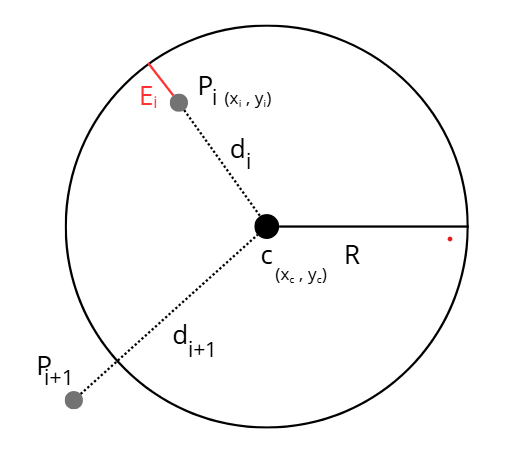

In [ ]:
# Lista para armazenar todos os erros individuais com metadados
detailed_errors_esp = []

# Lista para armazenar estatísticas por volta
summary_esp = []

for lap_name in laps.keys():
    lap_df = laps[lap_name]["esp32"].get("dataframe")
    
    if lap_df is None or lap_df.empty:
        continue

    radial_errors_esp = []
    
    for _, lap_point in lap_df.iterrows():
        # Distância geodésica entre ponto GNSS e centro do pivô
        distance = geodesic(
            (pivot_lat, pivot_long),
            (lap_point['latitude'], lap_point['longitude'])
        ).meters

        error = abs(radius_m - distance)
        radial_errors_esp.append(error)

        # Armazena o erro com a volta e dispositivo
        detailed_errors_esp.append({
            'Volta': lap_name,
            'Dispositivo': 'ESP32',
            'Erro Radial': error
        })

    # Estatísticas da volta
    emp_esp = np.mean(radial_errors_esp)
    std_dev_esp = np.std(radial_errors_esp)
    _2sigma_esp = 2 * std_dev_esp

    summary_esp.append({
        'Volta': lap_name,
        'Dispositivo': 'ESP32',
        'EMP': emp_esp,
        'Desvio Padrão': std_dev_esp,
        '2σ': _2sigma_esp,
        'N Pontos': len(radial_errors_esp)
    })

# DataFrame com erros individuais
errors_esp_df = pd.DataFrame(detailed_errors_esp)

# DataFrame com resumo estatístico por volta
summary_esp_df = pd.DataFrame(summary_esp)


In [81]:
errors_esp_df

,Volta,Dispositivo,Erro Radial
0,lap_1,ESP32,0.555647
1,lap_1,ESP32,0.859967
2,lap_1,ESP32,0.095065
3,lap_1,ESP32,0.578553
4,lap_1,ESP32,0.356607
...,...,...,...
4069,lap_6,ESP32,3.776564
4070,lap_6,ESP32,5.732910
4071,lap_6,ESP32,4.587518
4072,lap_6,ESP32,1.067829


In [80]:
summary_esp_df

,Volta,Dispositivo,EMP,Desvio Padrão,2σ,N Pontos
0,lap_1,ESP32,0.705917,0.444323,0.888645,670
1,lap_2,ESP32,1.013553,0.609432,1.218864,661
2,lap_3,ESP32,2.954574,2.730727,5.461454,702
3,lap_4,ESP32,1.624276,0.851876,1.703751,702
4,lap_5,ESP32,4.027585,2.151449,4.302898,707
5,lap_6,ESP32,3.441330,1.793889,3.587779,632


In [83]:
# Lista para armazenar todos os erros individuais com metadados
detailed_errors_celular = []

# Lista para armazenar estatísticas por volta
summary_celular = []

for lap_name in laps.keys():
    lap_df = laps[lap_name]["celular"].get("dataframe")
    
    if lap_df is None or lap_df.empty:
        continue

    radial_errors_celular = []
    
    for _, lap_point in lap_df.iterrows():
        # Distância geodésica entre ponto GNSS e centro do pivô
        distance = geodesic(
            (pivot_lat, pivot_long),
            (lap_point['latitude'], lap_point['longitude'])
        ).meters

        error = abs(radius_m - distance)
        radial_errors_celular.append(error)

        # Armazena o erro com a volta e dispositivo
        detailed_errors_celular.append({
            'Volta': lap_name,
            'Dispositivo': 'Celular',
            'Erro Radial': error
        })

    # Estatísticas da volta
    emp_celular = np.mean(radial_errors_celular)
    std_dev_celular = np.std(radial_errors_celular)
    _2sigma_celular = 2 * std_dev_celular

    summary_celular.append({
        'Volta': lap_name,
        'Dispositivo': 'Celular',
        'EMP': emp_celular,
        'Desvio Padrão': std_dev_celular,
        '2σ': _2sigma_celular,
        'N Pontos': len(radial_errors_celular)
    })

# DataFrame com erros individuais
errors_celular_df = pd.DataFrame(detailed_errors_celular)

# DataFrame com resumo estatístico por volta
summary_celular_df = pd.DataFrame(summary_celular)


In [84]:
errors_celular_df

,Volta,Dispositivo,Erro Radial
0,lap_1,Celular,4.531507
1,lap_1,Celular,0.833364
2,lap_1,Celular,1.535477
3,lap_1,Celular,2.416379
4,lap_1,Celular,2.995398
...,...,...,...
3834,lap_6,Celular,5.568702
3835,lap_6,Celular,3.450592
3836,lap_6,Celular,0.397346
3837,lap_6,Celular,4.076514


In [85]:
summary_celular_df

,Volta,Dispositivo,EMP,Desvio Padrão,2σ,N Pontos
0,lap_1,Celular,1.844815,1.320613,2.641226,432
1,lap_2,Celular,1.350352,0.964407,1.928814,720
2,lap_3,Celular,1.521663,1.145849,2.291697,720
3,lap_4,Celular,2.167926,1.386282,2.772564,640
4,lap_5,Celular,3.032500,1.649047,3.298094,606
5,lap_6,Celular,2.793503,1.492261,2.984522,721


In [86]:
from geopy.distance import geodesic
import pandas as pd
import numpy as np

# Lista para armazenar todos os erros individuais com metadados
detailed_errors_garmin = []

# Lista para armazenar estatísticas por volta
summary_garmin = []

for lap_name in laps.keys():
    lap_df = laps[lap_name]["garmin"].get("dataframe")
    
    if lap_df is None or lap_df.empty:
        continue

    radial_errors_garmin = []
    
    for _, lap_point in lap_df.iterrows():
        # Distância geodésica entre ponto GNSS e centro do pivô
        distance = geodesic(
            (pivot_lat, pivot_long),
            (lap_point['latitude'], lap_point['longitude'])
        ).meters

        error = abs(radius_m - distance)
        radial_errors_garmin.append(error)

        # Armazena o erro com a volta e dispositivo
        detailed_errors_garmin.append({
            'Volta': lap_name,
            'Dispositivo': 'Garmin',
            'Erro Radial': error
        })

    # Estatísticas da volta
    emp_garmin = np.mean(radial_errors_garmin)
    std_dev_garmin = np.std(radial_errors_garmin)
    _2sigma_garmin = 2 * std_dev_garmin

    summary_garmin.append({
        'Volta': lap_name,
        'Dispositivo': 'Garmin',
        'EMP': emp_garmin,
        'Desvio Padrão': std_dev_garmin,
        '2σ': _2sigma_garmin,
        'N Pontos': len(radial_errors_garmin)
    })

# DataFrame com erros individuais
errors_garmin_df = pd.DataFrame(detailed_errors_garmin)

# DataFrame com resumo estatístico por volta
summary_garmin_df = pd.DataFrame(summary_garmin)


In [87]:
errors_garmin_df

,Volta,Dispositivo,Erro Radial
0,lap_1,Garmin,1.689519
1,lap_1,Garmin,0.819080
2,lap_1,Garmin,1.224814
3,lap_1,Garmin,1.988052
4,lap_1,Garmin,0.443927
...,...,...,...
4318,lap_6,Garmin,6.933983
4319,lap_6,Garmin,4.166564
4320,lap_6,Garmin,0.979920
4321,lap_6,Garmin,4.881356


In [88]:
summary_garmin_df

,Volta,Dispositivo,EMP,Desvio Padrão,2σ,N Pontos
0,lap_1,Garmin,1.307562,0.742596,1.485193,720
1,lap_2,Garmin,1.095016,0.836923,1.673845,721
2,lap_3,Garmin,1.458710,0.973866,1.947732,721
3,lap_4,Garmin,1.891484,1.077427,2.154854,720
4,lap_5,Garmin,3.783846,2.017445,4.034889,720
5,lap_6,Garmin,3.639549,1.919778,3.839557,721


# Volta 1 - 3 (5 m/s)

In [96]:
df_1_3 = pd.concat([summary_esp_df[0:3], summary_celular_df[0:3], summary_garmin_df[0:3]], axis=0)
df_1_3

,Volta,Dispositivo,EMP,Desvio Padrão,2σ,N Pontos
0,lap_1,ESP32,0.705917,0.444323,0.888645,670
1,lap_2,ESP32,1.013553,0.609432,1.218864,661
2,lap_3,ESP32,2.954574,2.730727,5.461454,702
0,lap_1,Celular,1.844815,1.320613,2.641226,432
1,lap_2,Celular,1.350352,0.964407,1.928814,720
2,lap_3,Celular,1.521663,1.145849,2.291697,720
0,lap_1,Garmin,1.307562,0.742596,1.485193,720
1,lap_2,Garmin,1.095016,0.836923,1.673845,721
2,lap_3,Garmin,1.458710,0.973866,1.947732,721


In [98]:
np.mean(df_1_3[0:3]["EMP"])

np.float64(1.5580148381156909)

In [101]:
# Calculate mean per device
device_means = df_1_3.groupby('Dispositivo')[['EMP', 'Desvio Padrão', '2σ']].mean().round(6)

# Define desired device order
device_order = ['ESP32', 'Celular', 'Garmin']
device_means.index = pd.CategoricalIndex(device_means.index, categories=device_order, ordered=True)
device_means = device_means.sort_index()

# Replace dot with comma for Word formatting
device_means = device_means.astype(str).apply(lambda col: col.str.replace('.', ','))

# Reset index for cleaner display
device_means = device_means.reset_index()

device_means

,Dispositivo,EMP,Desvio Padrão,2σ
0,ESP32,"1,558015","1,261494","2,522988"
1,Celular,"1,572277","1,143623","2,287246"
2,Garmin,"1,287096","0,851128","1,702257"


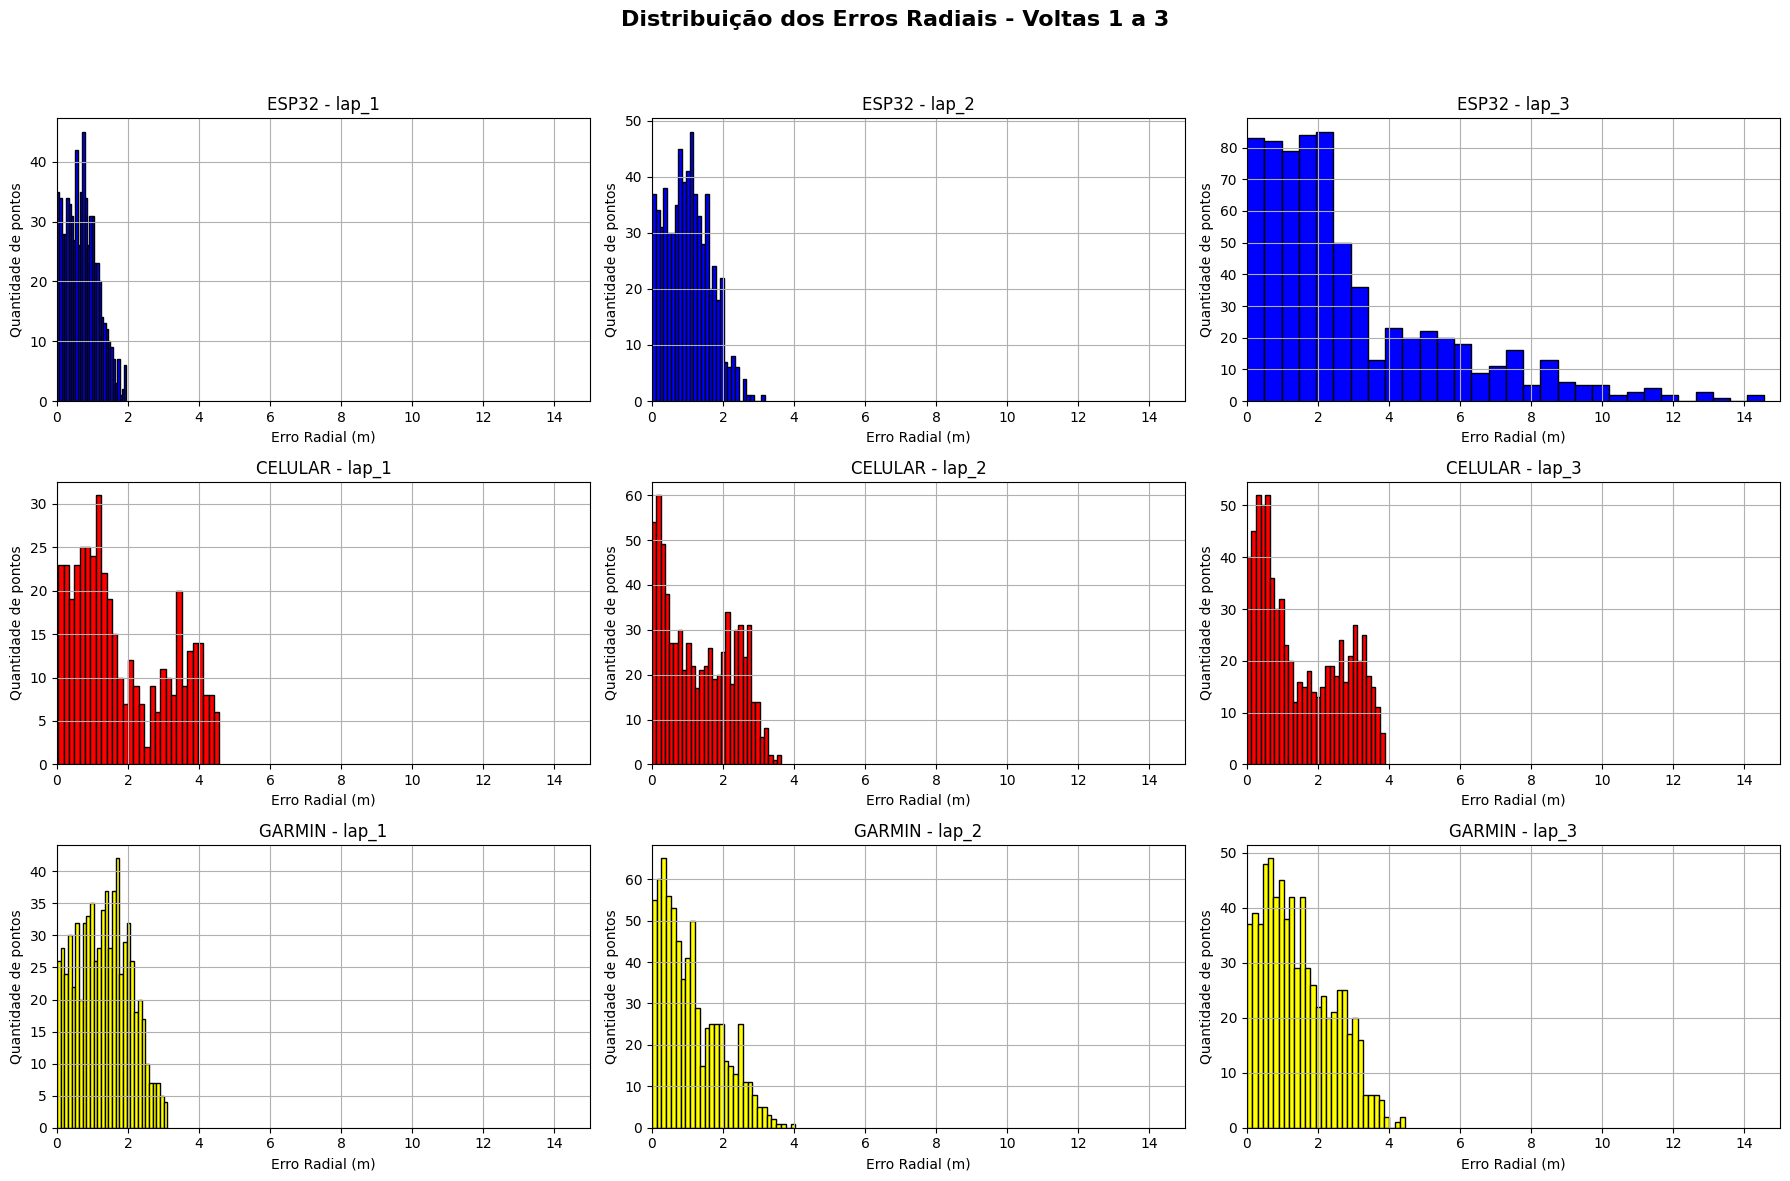

In [148]:
rows, cols = 3, 3

dispositivos = ['esp32', 'celular', 'garmin']
cores = {'esp32': 'blue', 'celular': 'red', 'garmin': 'yellow'}
dfs_erros = {
    'celular': errors_celular_df,
    'garmin': errors_garmin_df,
    'esp32': errors_esp_df
}

fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axs = axs.flatten()

fig.suptitle('Distribuição dos Erros Radiais - Voltas 1 a 3', fontsize=16, fontweight='bold')

i = 0
for dispositivo in dispositivos:
    df = dfs_erros[dispositivo]
    for volta in ['lap_1', 'lap_2', 'lap_3']:
        erros = df[(df['Volta'] == volta) & (df['Dispositivo'].str.lower() == dispositivo)]['Erro Radial'].values
        
        if len(erros) == 0:
            axs[i].axis('off')
            i += 1
            continue
        
        axs[i].hist(erros, bins=30, color=cores[dispositivo], edgecolor='black')
        axs[i].set_xlim(0, 15)  # <-- Aqui o limite do eixo X é fixado
        axs[i].set_title(f'{dispositivo.upper()} - {volta}')
        axs[i].set_xlabel('Erro Radial (m)')
        axs[i].set_ylabel('Quantidade de pontos')
        axs[i].grid(True)
        i += 1

# Oculta eixos extras se houver
for j in range(i, len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

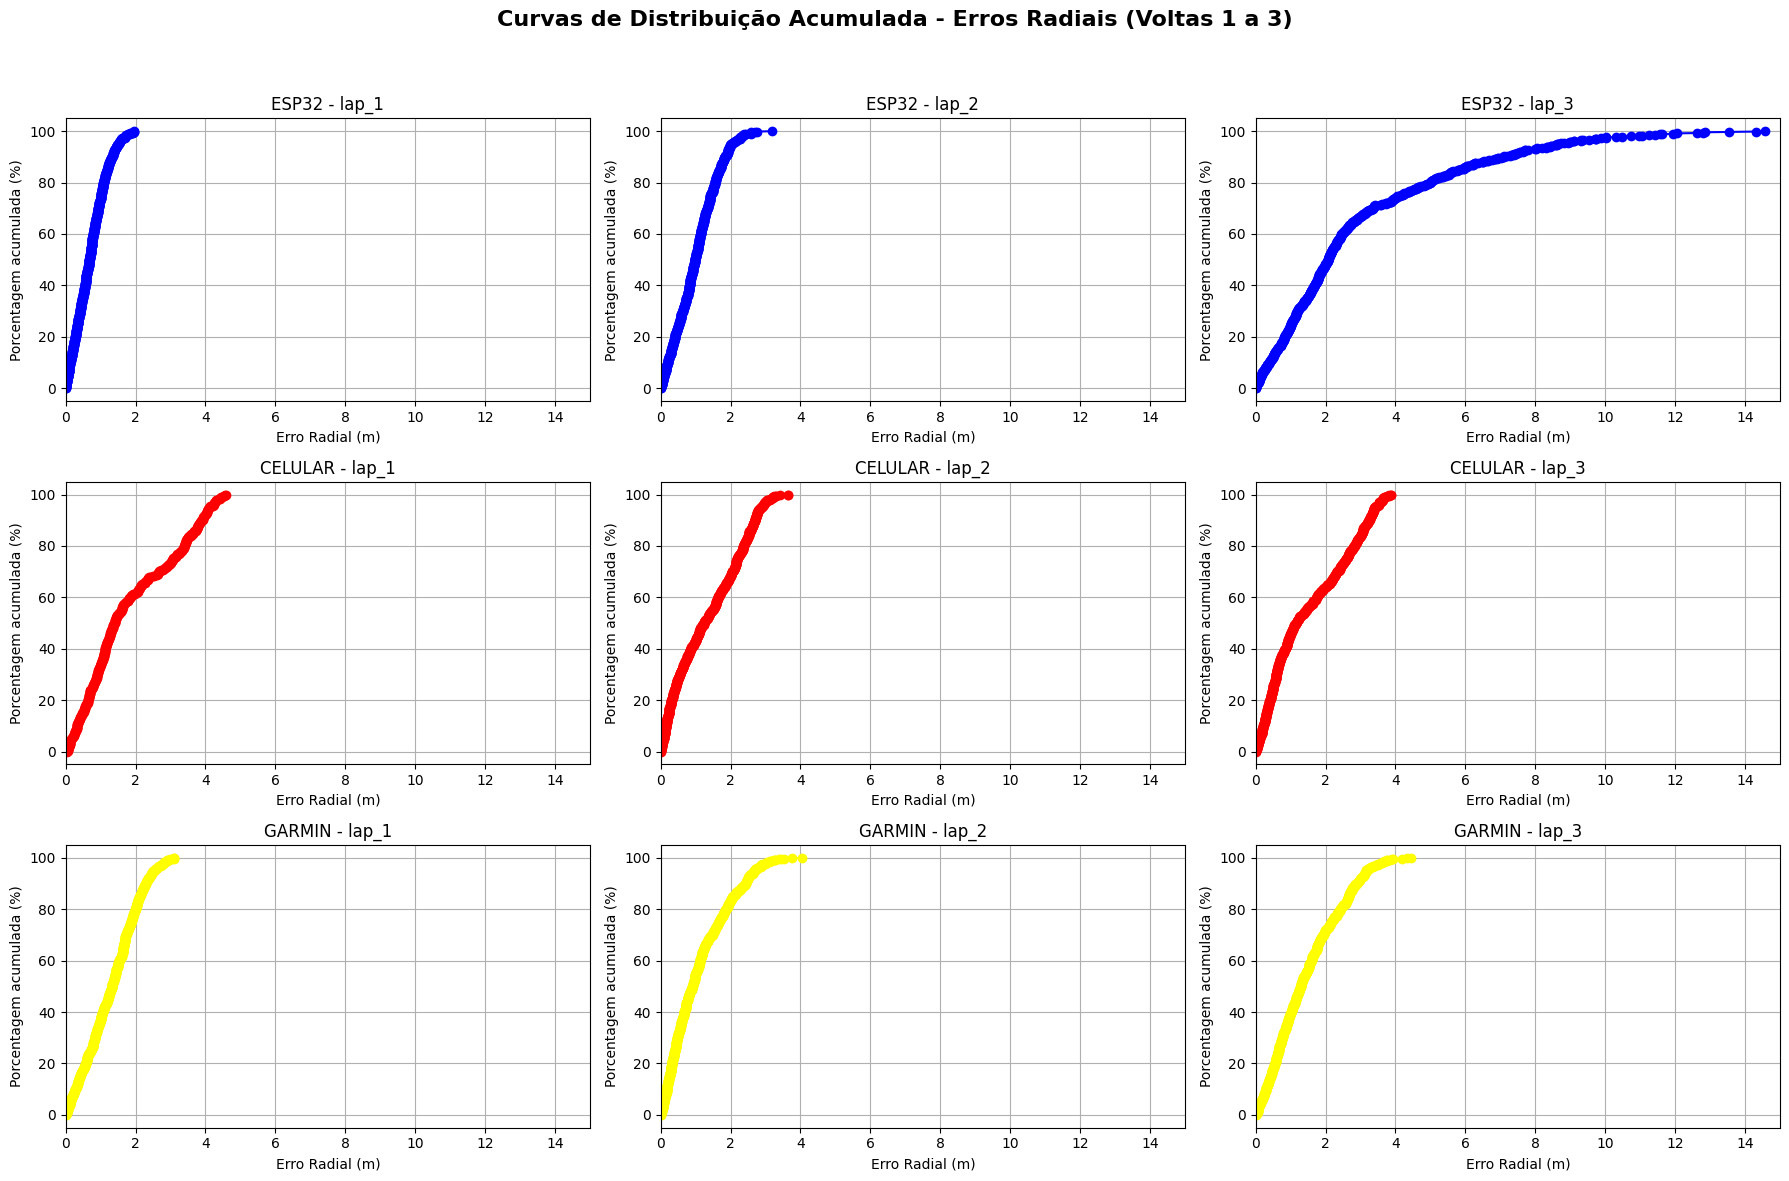

In [151]:
# Parâmetros da grade 3x3
rows, cols = 3, 3

# Lista de dispositivos e cores para diferenciar
dispositivos = ['esp32', 'celular', 'garmin']
cores = {'esp32': 'blue', 'celular': 'red', 'garmin': 'yellow', }
dfs_erros = {
    'celular': errors_celular_df,
    'garmin': errors_garmin_df,
    'esp32': errors_esp_df
}

# Cria os subplots
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axs = axs.flatten()

# Título geral
fig.suptitle('Curvas de Distribuição Acumulada - Erros Radiais (Voltas 1 a 3)', fontsize=16, fontweight='bold')

i = 0  # Índice para subplot
for dispositivo in dispositivos:
    df = dfs_erros[dispositivo]
    for volta in ['lap_1', 'lap_2', 'lap_3']:
        # Filtra erros da volta e dispositivo
        erros = df[(df['Volta'] == volta) & (df['Dispositivo'].str.lower() == dispositivo)]['Erro Radial'].values
        
        if len(erros) == 0:
            continue

        # Ordena os erros e calcula porcentagens acumuladas
        sorted_errors = np.sort(erros)
        percentages = np.linspace(0, 100, len(sorted_errors))

        # Plota no subplot correspondente
        axs[i].plot(sorted_errors, percentages, marker='o', linestyle='-', color=cores[dispositivo])
        axs[i].set_xlim(0, 15)  # <-- Aqui o limite do eixo X é fixado
        axs[i].set_title(f'{dispositivo.upper()} - {volta}')
        axs[i].set_xlabel('Erro Radial (m)')
        axs[i].set_ylabel('Porcentagem acumulada (%)')
        axs[i].grid(True)

        i += 1

# Desativa subplots extras
for j in range(i, len(axs)):
    axs[j].axis('off')

# Ajusta layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Volta 4 - 6 (2,5 m/s)

In [121]:
df_4_6 = pd.concat([summary_esp_df[3:6], summary_celular_df[3:6], summary_garmin_df[3:6]], axis=0)
df_4_6

,Volta,Dispositivo,EMP,Desvio Padrão,2σ,N Pontos
3,lap_4,ESP32,1.624276,0.851876,1.703751,702
4,lap_5,ESP32,4.027585,2.151449,4.302898,707
5,lap_6,ESP32,3.441330,1.793889,3.587779,632
3,lap_4,Celular,2.167926,1.386282,2.772564,640
4,lap_5,Celular,3.032500,1.649047,3.298094,606
5,lap_6,Celular,2.793503,1.492261,2.984522,721
3,lap_4,Garmin,1.891484,1.077427,2.154854,720
4,lap_5,Garmin,3.783846,2.017445,4.034889,720
5,lap_6,Garmin,3.639549,1.919778,3.839557,721


In [122]:
np.mean(df_4_6[0:3]["EMP"])

np.float64(3.031063567542326)

In [123]:
# Calculate mean per device
device_means = df_4_6.groupby('Dispositivo')[['EMP', 'Desvio Padrão', '2σ']].mean().round(6)

# Define desired device order
device_order = ['ESP32', 'Celular', 'Garmin']
device_means.index = pd.CategoricalIndex(device_means.index, categories=device_order, ordered=True)
device_means = device_means.sort_index()

# Replace dot with comma for Word formatting
device_means = device_means.astype(str).apply(lambda col: col.str.replace('.', ','))

# Reset index for cleaner display
device_means = device_means.reset_index()

device_means

,Dispositivo,EMP,Desvio Padrão,2σ
0,ESP32,"3,031064","1,599071","3,198143"
1,Celular,"2,664643","1,509197","3,018393"
2,Garmin,"3,10496","1,67155","3,3431"


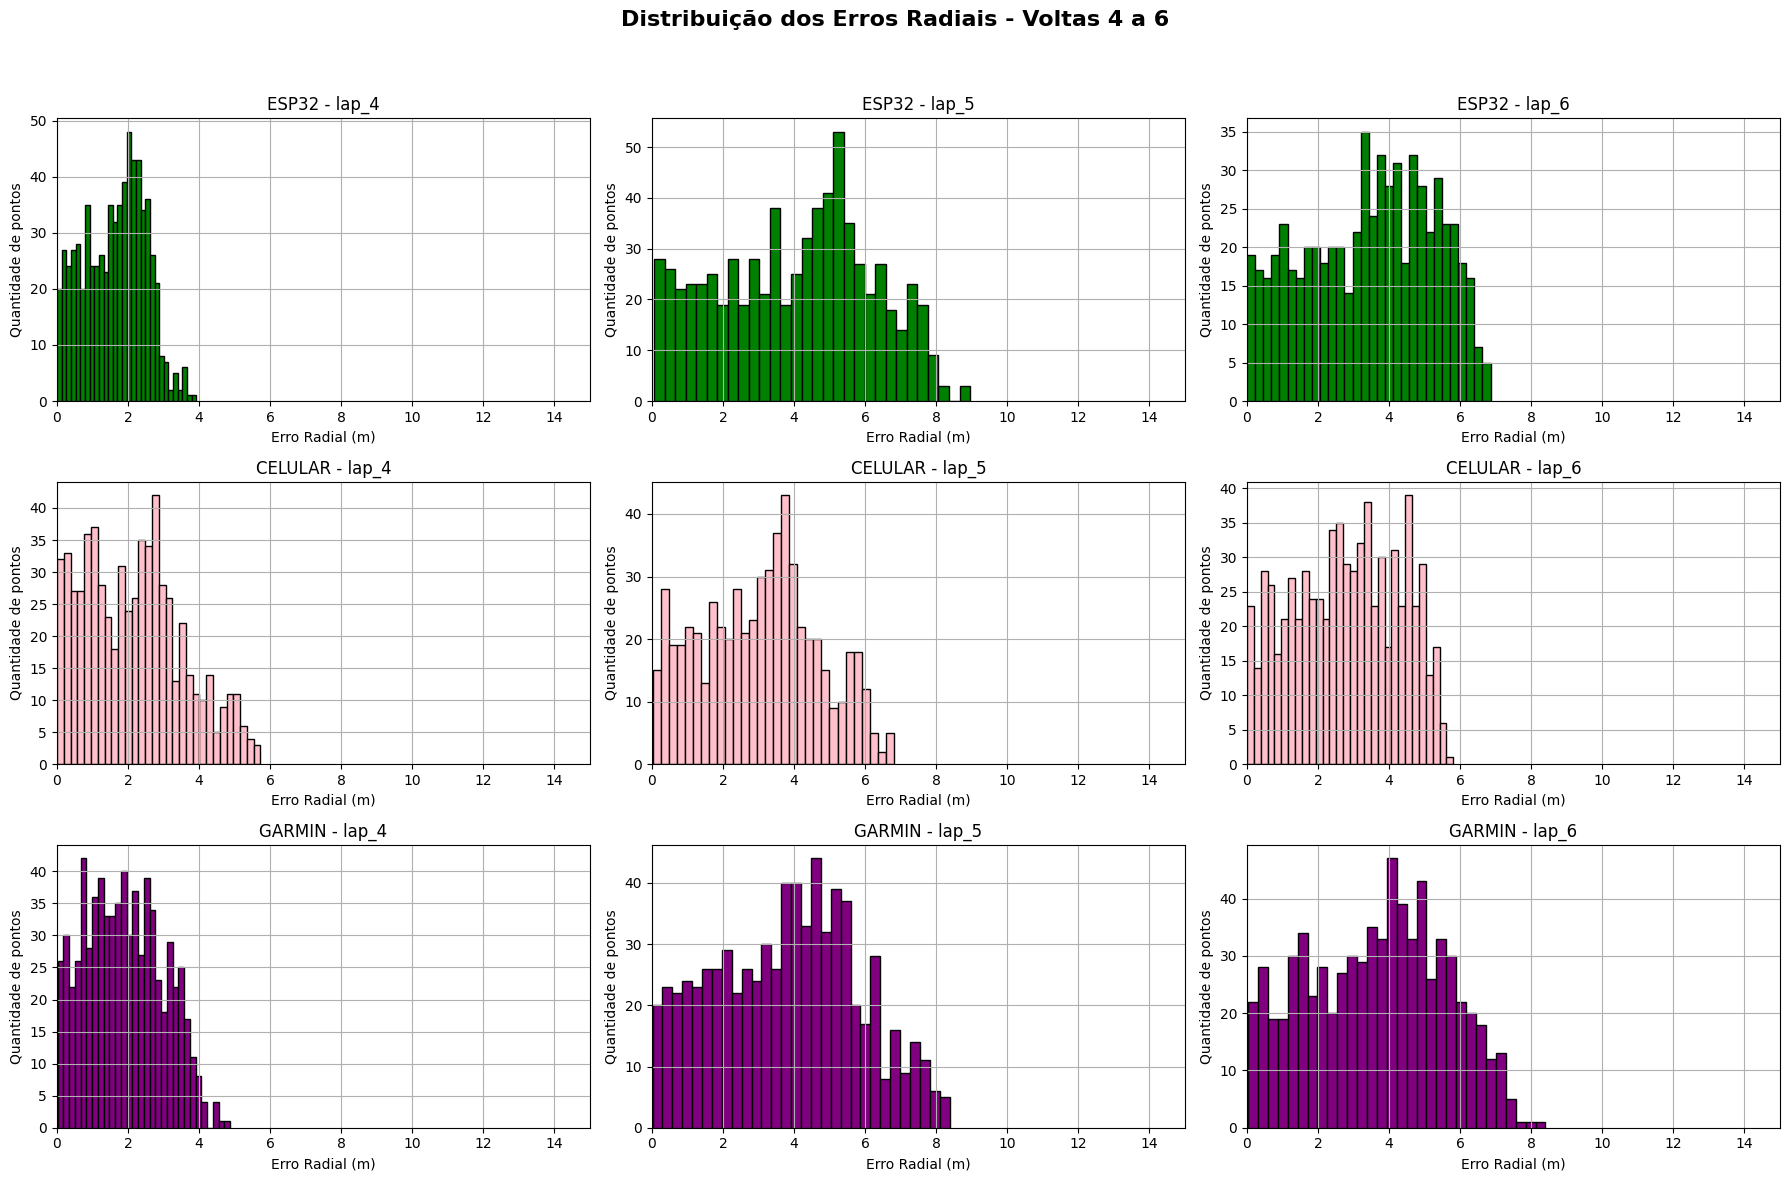

In [152]:
rows, cols = 3, 3

dispositivos = ['esp32', 'celular', 'garmin']
cores = {'celular': 'pink', 'garmin': 'purple', 'esp32': 'green'}
dfs_erros = {
    'celular': errors_celular_df,
    'garmin': errors_garmin_df,
    'esp32': errors_esp_df
}

fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axs = axs.flatten()

fig.suptitle('Distribuição dos Erros Radiais - Voltas 4 a 6', fontsize=16, fontweight='bold')

i = 0
for dispositivo in dispositivos:
    df = dfs_erros[dispositivo]
    for volta in ['lap_4', 'lap_5', 'lap_6']:
        erros = df[(df['Volta'] == volta) & (df['Dispositivo'].str.lower() == dispositivo)]['Erro Radial'].values
        
        if len(erros) == 0:
            axs[i].axis('off')
            i += 1
            continue
        
        axs[i].hist(erros, bins=30, color=cores[dispositivo], edgecolor='black')
        axs[i].set_xlim(0, 15)  # <-- Aqui o limite do eixo X é fixado
        axs[i].set_title(f'{dispositivo.upper()} - {volta}')
        axs[i].set_xlabel('Erro Radial (m)')
        axs[i].set_ylabel('Quantidade de pontos')
        axs[i].grid(True)
        i += 1

# Oculta eixos extras se houver
for j in range(i, len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

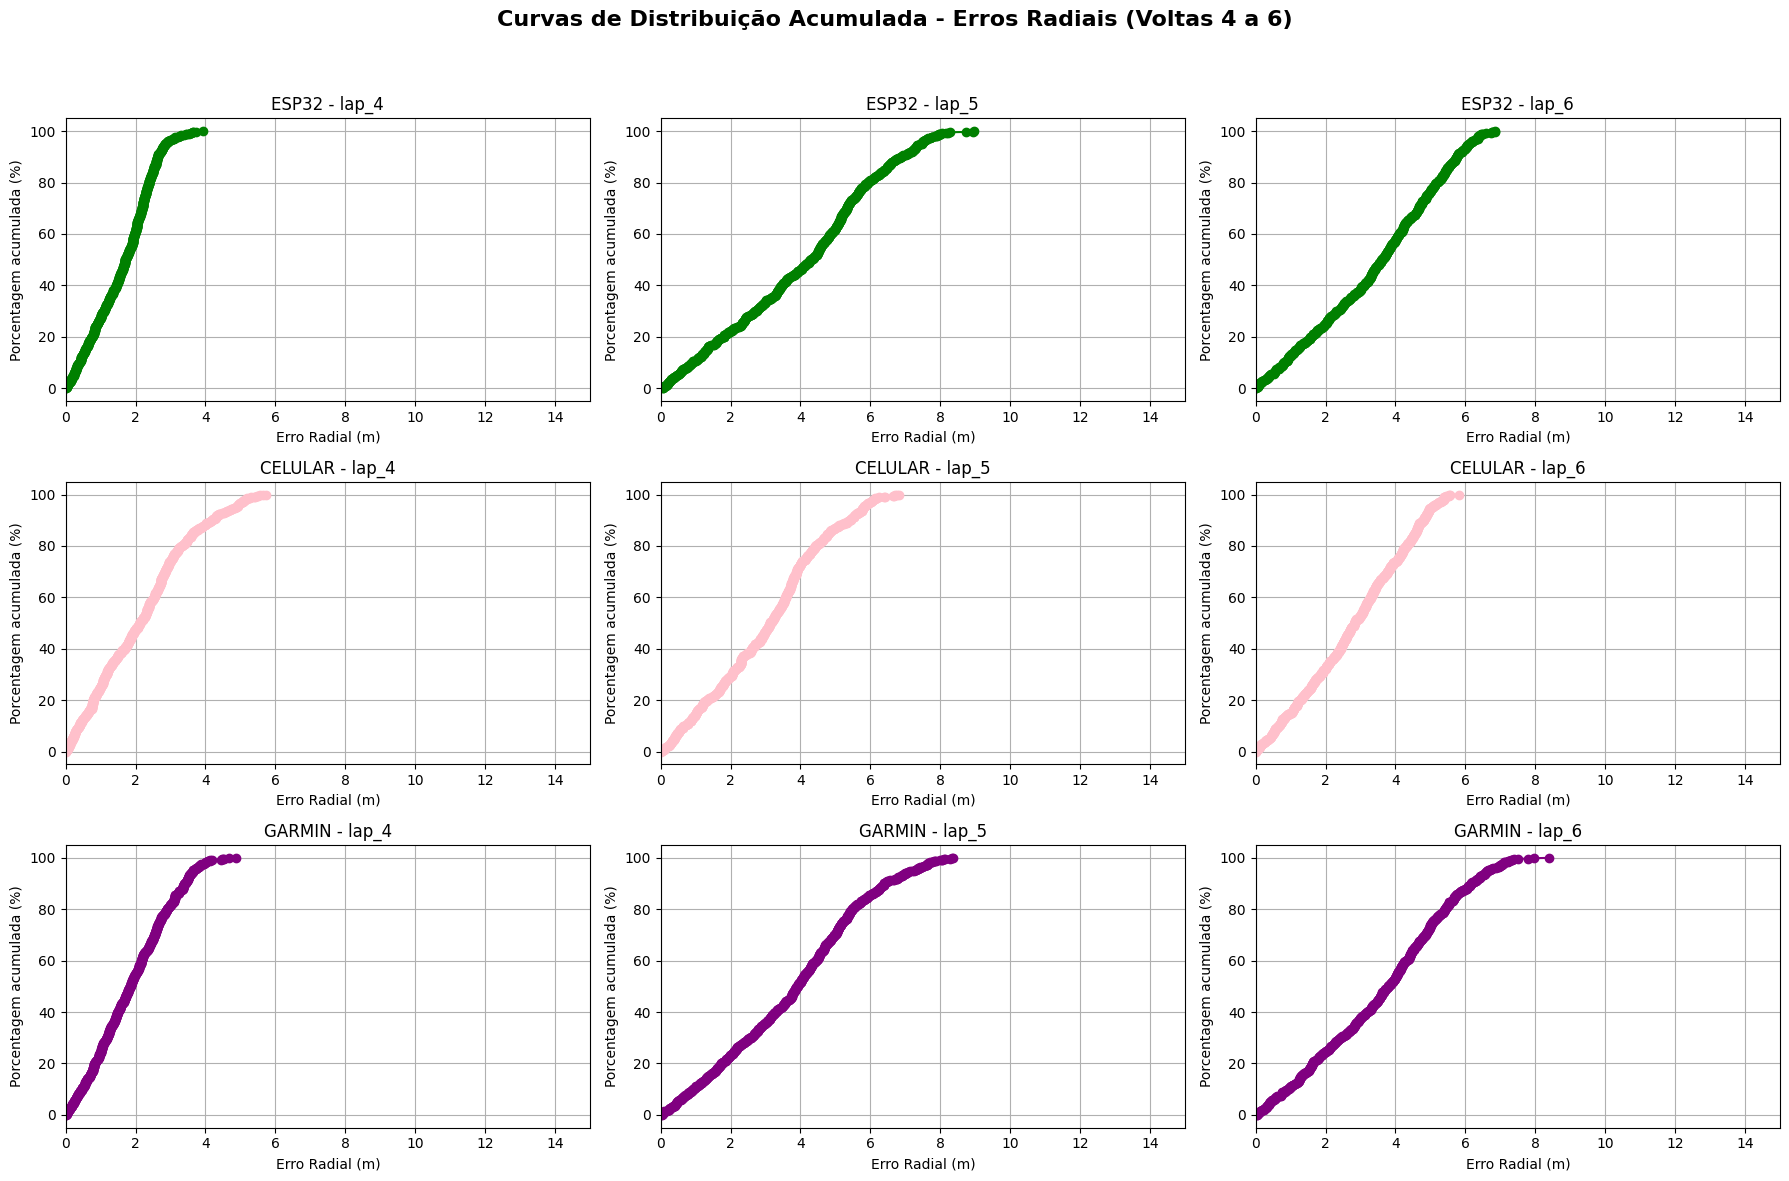

In [153]:
# Parâmetros da grade 3x3
rows, cols = 3, 3

# Lista de dispositivos e cores para diferenciar
dispositivos = ['esp32', 'celular', 'garmin']
cores = {'celular': 'pink', 'garmin': 'purple', 'esp32': 'green'}
dfs_erros = {
    'celular': errors_celular_df,
    'garmin': errors_garmin_df,
    'esp32': errors_esp_df
}

# Cria os subplots
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axs = axs.flatten()

# Título geral
fig.suptitle('Curvas de Distribuição Acumulada - Erros Radiais (Voltas 4 a 6)', fontsize=16, fontweight='bold')

i = 0  # Índice para subplot
for dispositivo in dispositivos:
    df = dfs_erros[dispositivo]
    for volta in ['lap_4', 'lap_5', 'lap_6']:
        # Filtra erros da volta e dispositivo
        erros = df[(df['Volta'] == volta) & (df['Dispositivo'].str.lower() == dispositivo)]['Erro Radial'].values
        
        if len(erros) == 0:
            continue

        # Ordena os erros e calcula porcentagens acumuladas
        sorted_errors = np.sort(erros)
        percentages = np.linspace(0, 100, len(sorted_errors))

        # Plota no subplot correspondente
        axs[i].plot(sorted_errors, percentages, marker='o', linestyle='-', color=cores[dispositivo])
        axs[i].set_xlim(0, 15)  # <-- Aqui o limite do eixo X é fixado
        axs[i].set_title(f'{dispositivo.upper()} - {volta}')
        axs[i].set_xlabel('Erro Radial (m)')
        axs[i].set_ylabel('Porcentagem acumulada (%)')
        axs[i].grid(True)

        i += 1

# Desativa subplots extras
for j in range(i, len(axs)):
    axs[j].axis('off')

# Ajusta layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Comparação 3 Dispositivos

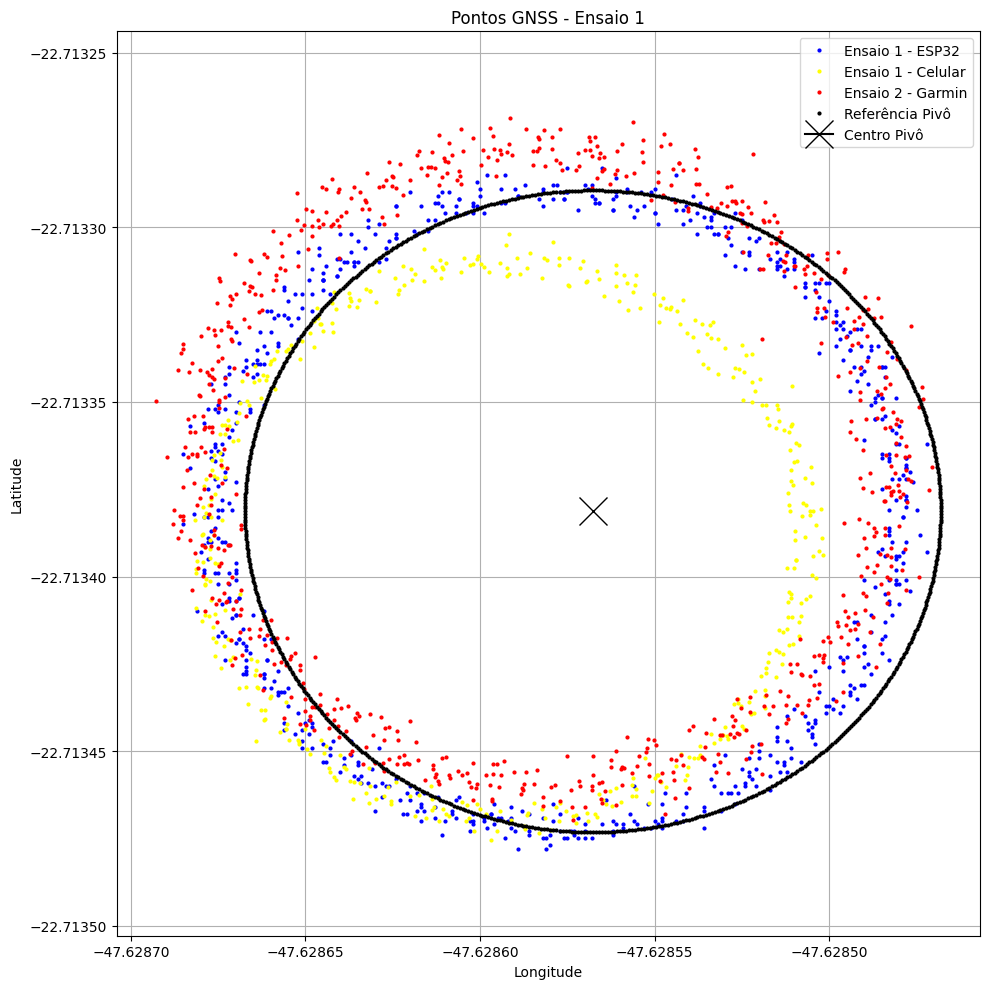

In [58]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot( laps['lap_1']["esp32"]["dataframe"]["longitude"], laps['lap_1']["esp32"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='blue', label="Ensaio 1 - ESP32")
ax.plot( laps['lap_1']["celular"]["dataframe"]["longitude"], laps['lap_1']["celular"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='yellow', label="Ensaio 1 - Celular")
ax.plot( laps['lap_1']["garmin"]["dataframe"]["longitude"], laps['lap_1']["garmin"]["dataframe"]["latitude"], marker='o', linestyle="", markersize=2, color='red', label="Ensaio 2 - Garmin")
ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=20, label="Centro Pivô")

ax.legend()

ax.set_title("Pontos GNSS - Ensaio 1")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.axis("equal")  # Mantém proporção correta
ax.ticklabel_format(useOffset=False)  # <--- ESSA LINHA REMOVE O OFFSET

plt.tight_layout()
plt.show()

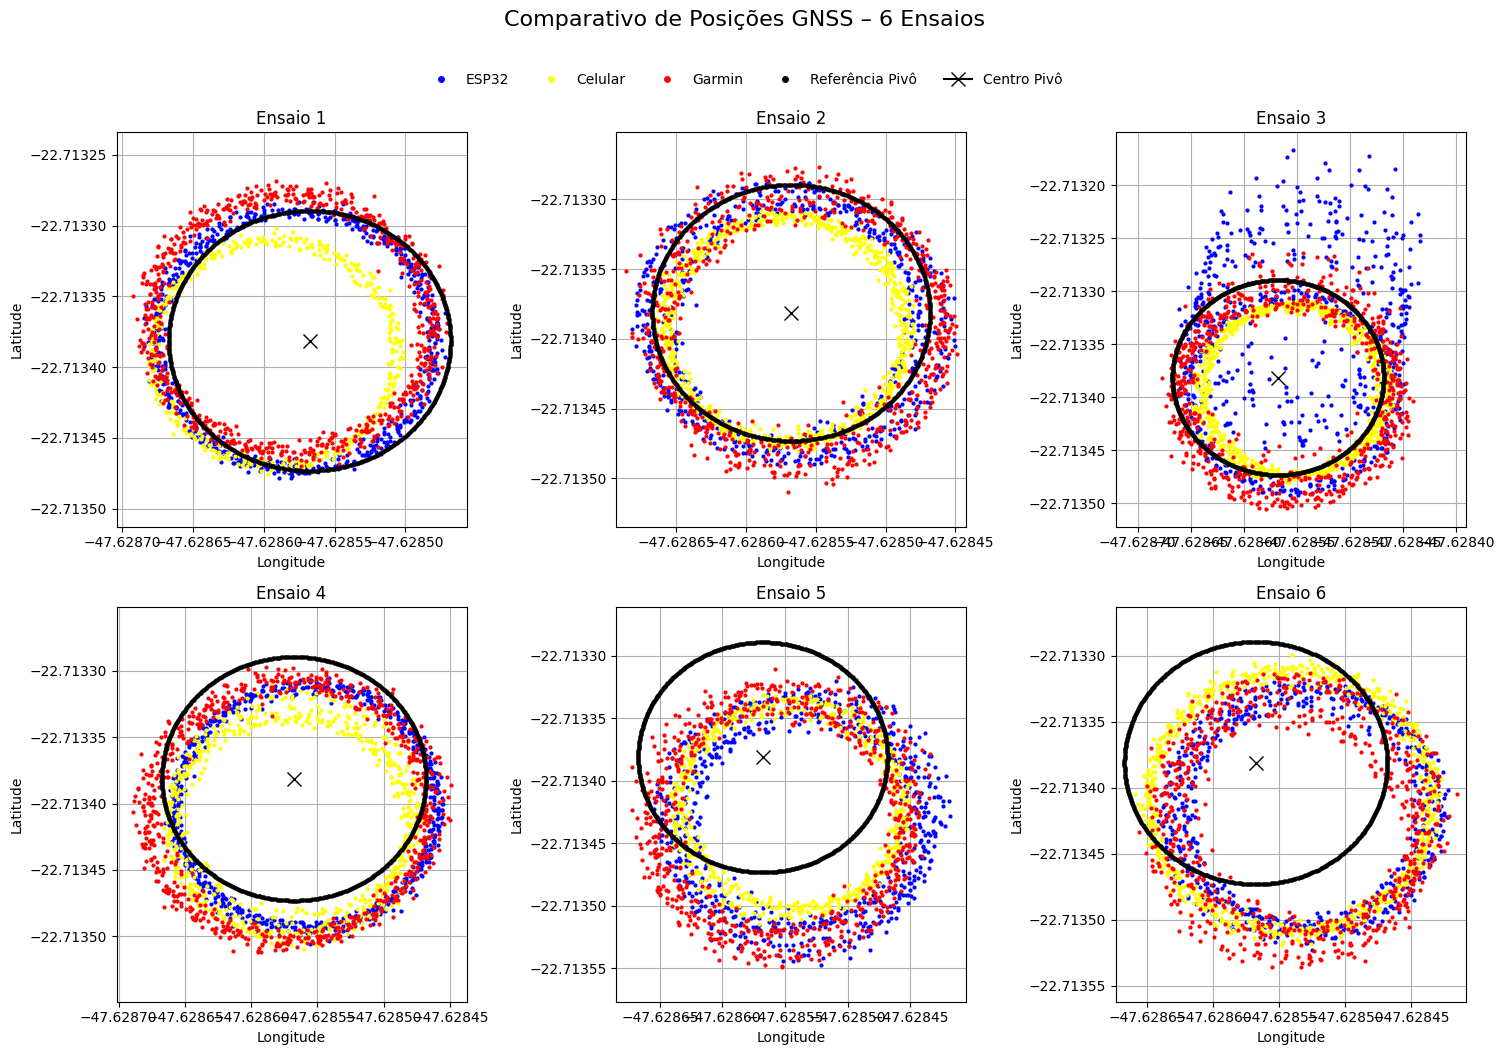

In [75]:
from matplotlib.lines import Line2D

# Configura o layout com 2 linhas e 3 colunas para 6 ensaios
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Faz um loop para iterar sobre os ensaios
for i in range(1, 7):  # De lap_1 a lap_6
    lap_name = f"lap_{i}"
    
    # Converte para um índice de subplot
    row = (i - 1) // 3
    col = (i - 1) % 3
    ax = axs[row, col]  # Seleciona o subplot correspondente
    
    # Títulos e labels para os subplots
    ax.set_title(f"Ensaio {i}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    

    ax.plot(laps[lap_name]["esp32"]["dataframe"]["longitude"], laps[lap_name]["esp32"]["dataframe"]["latitude"], 
                marker='o', linestyle="", markersize=2, color='blue', label="ESP32")
    
    
    ax.plot(laps[lap_name]["celular"]["dataframe"]["longitude"], laps[lap_name]["celular"]["dataframe"]["latitude"], 
                marker='o', linestyle="", markersize=2, color='yellow', label="Celular")
    
    
    ax.plot(laps[lap_name]["garmin"]["dataframe"]["longitude"], laps[lap_name]["garmin"]["dataframe"]["latitude"], 
                marker='o', linestyle="", markersize=2, color='red', label="Garmin")
    
    
    ax.plot(df_pivot["longitude"], df_pivot["latitude"], marker='o', linestyle="", markersize=2, color='black', label="Referência Pivô")
    ax.plot(pivot_long, pivot_lat, marker='x', color='black', markersize=10, label="Centro Pivô")
    

    # Ajusta o grid
    ax.grid(True)
    ax.axis("equal")  # Mantém a proporção correta
    ax.ticklabel_format(useOffset=False)  # Remove o offset das legendas


# Cria os handles da legenda global
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ESP32', markerfacecolor='blue', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Celular', markerfacecolor='yellow', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Garmin', markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Referência Pivô', markerfacecolor='black', markersize=6),
    Line2D([0], [0], marker='x', color='black', label='Centro Pivô', markersize=10)
]


# Adiciona um título geral
fig.suptitle("Comparativo de Posições GNSS – 6 Ensaios", fontsize=16, y=1.05)

# Adiciona a legenda global acima dos subplots
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1),ncol=5, frameon=False)


# Ajuste no layout para que os subplots não se sobreponham
plt.tight_layout()
plt.show()


In [80]:
# Listas para armazenar os dados de erro
error_data_esp32 = []
error_data_cellular = []
error_data_garmin = []

# Lista de dispositivos e dicionário para mapear os dados
devices = ['esp32', 'celular', 'garmin']
data_by_device = {
    'esp32': error_data_esp32,
    'celular': error_data_cellular,
    'garmin': error_data_garmin
}

# Itera sobre as voltas e coleta as métricas dos dispositivos
for lap_name in laps.keys():
    for device in devices:
        error = laps[lap_name].get(device, {}).get('error_analysis')
        if error:
            data_by_device[device].append({
                'EMP': error['mean_euclidean_error_m'],
                'EM/L-O': error['mean_ew_error_m'],
                'EM/N-S': error['mean_ns_error_m'],
                'DP': error['std_euclidean_error_m'],
                'DP/L-O': error['std_ew_error_m'],
                'DP/N-S': error['std_ns_error_m'],
                '2σ': error['2sigma_m'],
                'CEP': error['cep_m'],
                'Max Error': error['max_euclidean_error_m'],
                'Min Error': error['min_euclidean_error_m'],
                'Number of Points': error['num_points']
            })

# Converte listas em DataFrames
df_esp32 = pd.DataFrame(error_data_esp32)
df_cellular = pd.DataFrame(error_data_cellular)
df_garmin = pd.DataFrame(error_data_garmin)

# Calcula médias
mean_esp32 = df_esp32.mean(numeric_only=True)
mean_cellular = df_cellular.mean(numeric_only=True)
mean_garmin = df_garmin.mean(numeric_only=True)

# Monta DataFrame final com as médias
df_mean = pd.DataFrame({
    'Device': ['ESP32', 'Celular', 'Garmin'],
    'EMP': [mean_esp32['EMP'], mean_cellular['EMP'], mean_garmin['EMP']],
    'EM/L-O': [mean_esp32['EM/L-O'], mean_cellular['EM/L-O'], mean_garmin['EM/L-O']],
    'EM/N-S': [mean_esp32['EM/N-S'], mean_cellular['EM/N-S'], mean_garmin['EM/N-S']],
    'DP': [mean_esp32['DP'], mean_cellular['DP'], mean_garmin['DP']],
    'DP/L-O': [mean_esp32['DP/L-O'], mean_cellular['DP/L-O'], mean_garmin['DP/L-O']],
    'DP/N-S': [mean_esp32['DP/N-S'], mean_cellular['DP/N-S'], mean_garmin['DP/N-S']],
    '2σ': [mean_esp32['2σ'], mean_cellular['2σ'], mean_garmin['2σ']],
    'CEP': [mean_esp32['CEP'], mean_cellular['CEP'], mean_garmin['CEP']],
    'Max Error': [mean_esp32['Max Error'], mean_cellular['Max Error'], mean_garmin['Max Error']],
    'Min Error': [mean_esp32['Min Error'], mean_cellular['Min Error'], mean_garmin['Min Error']],
    'Number of Points': [mean_esp32['Number of Points'], mean_cellular['Number of Points'], mean_garmin['Number of Points']]
})

# Exibe as médias finais
df_mean


,Device,EMP,EM/L-O,EM/N-S,DP,DP/L-O,DP/N-S,2σ,CEP,Max Error,Min Error,Number of Points
0,ESP32,2.299133,0.658799,-0.812738,1.431742,1.453855,1.651753,2.863484,2.609045,6.575962,0.015113,679.000000
1,Celular,2.115862,0.275680,-1.100768,1.319504,1.460813,1.447000,2.639007,2.427024,5.052287,0.015077,639.833333
2,Garmin,2.202490,0.337623,-1.177665,1.267600,1.341334,1.463375,2.535199,2.344008,5.579058,0.016103,720.500000
